In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import scipy.stats as stats
import plotly.express as px
from Data_cleaning_utils import perform_data_cleaning
sns.set_style('white')
sns.set_palette('pastel')
import warnings
warnings.filterwarnings('ignore')


In [142]:
cleaned_df = perform_data_cleaning(file_path = r"C:\Users\User\delivery-time-prediction\data\raw\swiggy.csv")
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45502 entries, 0 to 45592
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   rider_id             45502 non-null  object  
 1   age                  43648 non-null  float64 
 2   ratings              43594 non-null  float64 
 3   restaurant_lat       41872 non-null  float64 
 4   restaurant_long      41872 non-null  float64 
 5   delivery_lat         41872 non-null  float64 
 6   delivery_long        41872 non-null  float64 
 7   weather              44977 non-null  object  
 8   traffic              44992 non-null  object  
 9   vehicle_condition    45502 non-null  int64   
 10  order_type           45502 non-null  object  
 11  vehicle_type         45502 non-null  object  
 12  multiple_deliveries  44509 non-null  float64 
 13  festival             45274 non-null  object  
 14  city_type            44304 non-null  object  
 15  time                 455

# EDA Function Template

In [143]:
# Univariate Numerical
def uni_num(cols):

        # Distribution and Boxplots
        fig = plt.figure(figsize=(15,8))
        grid = GridSpec(2,2,figure = fig)

        ax1 = fig.add_subplot(grid[0,0])
        ax2 = fig.add_subplot(grid[0,1])
        ax3 = fig.add_subplot(grid[1,0])
        ax4 = fig.add_subplot(grid[1,1])

        sns.histplot(cleaned_df[cols],kde=True,bins='auto',ax=ax3)
        ax3.set_title('Histogram')

        sns.boxplot(x=cleaned_df[cols],ax=ax2)
        ax2.set_title('Boxplot')

        sns.kdeplot(x=cleaned_df[cols],ax=ax1,color="lightgreen",fill=True)
        ax1.set_title('Kdensity')

        stats.probplot(cleaned_df[cols],dist="norm",plot=ax4)
        ax4.set_title("Q-Q Plot")
    

        plt.tight_layout()
        plt.show()
        

        test_df = cleaned_df.dropna()
        # Descriptive Statistics
        print(cleaned_df[cols].describe(), "\n")

        # Normality Test and Skewness
        print(f"Skewness : {cleaned_df[cols].skew()}", "\n")

        if (cleaned_df[cols].skew() > -0.5) & (cleaned_df[cols].skew() < 0.5):
            print(f"Data is relativly normally distributed" , "\n")
        else:
            print(f"Data is not normal,Some Feature Transformation may help" , "\n")

        print(f"------Shapiro wilk test of Normality----------", "\n")

        print(f"p_value for Shapiro wilk : {stats.shapiro(test_df[cols]).pvalue:.4f}", "\n")
        if stats.shapiro(test_df[cols]).pvalue < 0.05:
            print("Data is not normally distributed" , "\n")
        else:
            print("Data is normally distributed" , "\n")

        # Outliers test and Kurtosis
        print(f"------Outliers test----------", "\n")
        q1 = np.percentile(cleaned_df[cols], 25)
        q3 = np.percentile(cleaned_df[cols], 75)
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        print(f"Upper Bound is {upper_bound} and Lower Bound is {lower_bound}")

        if (cleaned_df[cols] < lower_bound).any() or (cleaned_df[cols] > upper_bound).any():
            print("Data has outliers" , "\n")
        else:
            print("Data does not have outliers" , "\n")
        
        print(f"Kurtosis : {cleaned_df[cols].kurt()}", "\n")
        
        if (cleaned_df[cols].kurt() > -1.0) & (cleaned_df[cols].kurt() < 1.0):
            print(f"No extreme outliers present" , "\n")
        else:
            print(f"Some Feature Transformation may help" , "\n") 


# Univariate Categorical
def uni_cat(cols):

    fig = plt.figure(figsize=(15,8))

    grid = GridSpec(1,2)

    ax1 = fig.add_subplot(grid[0,0])
    ax2 = fig.add_subplot(grid[0,1])

    
    sns.barplot(x=cleaned_df[cols].value_counts().index,y=cleaned_df[cols].value_counts().values,ax=ax1)
    for names,counts in enumerate(cleaned_df[cols].value_counts()):
        ax1.text(names,counts, str(counts),ha='center',va='bottom')
        
    ax1.set_title('Barplot')

    cleaned_df[cols].value_counts().plot(kind='pie',autopct='%1.1f%%',ax=ax2)
    ax2.set_title('Piechart')

    
    plt.tight_layout()
    plt.show()

    print(f"There are {cleaned_df[cols].nunique()} unique values in {cols} column", "\n")

    print(f"There are {((cleaned_df[cols].isnull().sum()) / len(cleaned_df[cols])).round(2)*100}% missing values in {cols} column", "\n")

    print(cleaned_df[cols].value_counts(), "\n")


# Bivariate Numerical Categorical
def num_cat(num_col,cat_col,estimator=np.mean):
    # visualization

    fig = plt.figure(figsize=(15,8))

    grid = GridSpec(2,2,figure=fig)

    ax1 = fig.add_subplot(grid[0,0])
    ax2 = fig.add_subplot(grid[0,1])
    ax3 = fig.add_subplot(grid[1,0])
    ax4 = fig.add_subplot(grid[1,1])

    sns.barplot(x=cleaned_df[cat_col],y=cleaned_df[num_col], hue=cleaned_df[cat_col], legend=False,palette="pastel",estimator=estimator,ax=ax1)

    sns.boxplot(x=cleaned_df[cat_col],y=cleaned_df[num_col],hue=cleaned_df[cat_col],legend=False,palette="pastel" ,ax=ax2)

    sns.violinplot(x=cleaned_df[cat_col],y=cleaned_df[num_col],hue=cleaned_df[cat_col],legend=False,palette="pastel" ,ax=ax3)

    sns.stripplot(x=cleaned_df[cat_col],y=cleaned_df[num_col],hue=cleaned_df[cat_col],legend=False,palette="pastel", alpha=0.5, jitter=0.2,ax=ax4)

    # Mean Difference Test

    test_df = cleaned_df.dropna()

    category_list = test_df[cat_col].value_counts().index.tolist()
    groups = []
        
    for category in category_list:
        lists = test_df[test_df[cat_col] == category][num_col]

        groups.append(lists)

    if cleaned_df[cat_col].nunique() > 2:

        # groups = [test_df[num_col][test_df[cat_col] == category] for category in test_df[cat_col].unique()]

        f_stat,p_value = stats.f_oneway(*groups)

        print(f"p_value : {p_value:.4f}", "\n")

        if p_value < 0.05:
            print("Atleast one group has mean that is significantly different", "\n")
        else:
            print("There is no significant difference between the means of the groups", "\n")
    else:
        # groups = [test_df[num_col][test_df[cat_col] == category] for category in test_df[cat_col].unique()]

        f_stat,p_value = stats.ttest_ind(*groups)

        print(f"p_value : {p_value:.4f}", "\n")

        if p_value < 0.05:
                print("There is a significant difference between the means of the groups", "\n")
        else:
                print("There is no significant difference between the means of the groups", "\n")

# Categorical Categorical
def cat_cat(cols1,cols2):
    fig = px.imshow(pd.crosstab(cleaned_df[cols1],cleaned_df[cols2]),
                    text_auto=True, color_continuous_scale='blues', aspect="auto")
    fig.show()


    test_df = cleaned_df.dropna()

    contingency_table = pd.crosstab(test_df[cols1],test_df[cols2])

    ch2_stat,p_value,_,_ = stats.chi2_contingency(contingency_table)
    print(f"The P_value is {p_value: .4f}")

    if p_value < 0.05:
        print(f"There is a significant association between {cols1} and {cols2}", "\n")
    else:
        print(f"There is no significant association between {cols1} and {cols2}", "\n")


# Numerical Nvs Numerical Analysis

def num_num(num_col2,num_col1):

    fig = plt.figure(figsize=(15,8))

    grid = GridSpec(2,2,figure = fig)

    ax1 = fig.add_subplot(grid[0,0])
    ax2 = fig.add_subplot(grid[0,1])
    ax3 = fig.add_subplot(grid[1,:])
    
    sns.scatterplot(x=cleaned_df[num_col1],y=cleaned_df[num_col2],alpha=0.7,
                        edgecolor='white',linewidth=1.5,ax=ax1)
    ax1.set_title("Scatterplot")
    
    sns.lineplot(x=cleaned_df[num_col1],y=cleaned_df[num_col2],errorbar='sd',ax=ax2)
    ax2.set_title("Linechart")

    sns.regplot(x=cleaned_df[num_col1],y=cleaned_df[num_col2],ci=95,
               scatter_kws={'alpha':0.6}, line_kws={'color':'red'},ax=ax3)
    ax3.set_title("Regression Plot")
    
    plt.tight_layout()
    plt.show()
    
    # Statistical tests

    test_df = cleaned_df.dropna()
    pearson_coef,p_value_pearson = stats.pearsonr(x=test_df[num_col1],y=test_df[num_col2])

    print(f"Pearson Correlation test is reliable if both data is normally distributed or their relationship is linear.")
    print(f"pearson coeffient = {pearson_coef: .4f} and p_value = {p_value_pearson: .4f}")

    if p_value_pearson < 0.05 :
        print(f"We Reject The Null Hypothesis of No significant Realtionship.")
    else:
        print(f"There is No relation between {num_col2} and {num_col1}")
    
    print("-"*50)

    spearman_coef,p_value_spearman = stats.spearmanr(test_df[num_col1],test_df[num_col2])

    print(f"Spearman Correlation Rank test is reliable without assuming any distribution of the data and their relationship is not linear.")
    print(f"Spearman coeffient = {spearman_coef: .4f} and p_value = {p_value_spearman: .4f}")

    if p_value_spearman < 0.05 :
        print(f"We Reject The Null Hypothesis of No significant Realtionship.")
    else:
        print(f"There is No relation between {num_col2} and {num_col1}")
    
    print("-"*50)

    result = stats.linregress(x=test_df[num_col1], y=test_df[num_col2])

    print("Simple Linear Regresson Test (OLS)","\n")
    print(f"coefficient = {result.slope: .4f} and p_value = {result.pvalue: .4f}")
    print(f"A 1 unit change in {num_col1} is correlated with {result.slope: .4f} Unit change in {num_col2}")
    print(f"R2 value = {result.rvalue ** 2 : .4f}")
    print(f"{(result.rvalue ** 2)*100 : .4f}% of total variation in {num_col2} Can be explained by {num_col1}")

    if result.pvalue < 0.05 :
        print(f"We Reject The Null Hypothesis of No significant Realtionship.")
    else:
        print(f"There is No relation between {num_col2} and {num_col1}")



# Multivariate Analysis
def multivariate_analysis(num_col,cat_col1,cat_col2,estimator=np.mean):

    fig = plt.figure(figsize=(15,8))

    grid = GridSpec(2,2,figure=fig)

    ax1 = fig.add_subplot(grid[0,0])
    ax2 = fig.add_subplot(grid[0,1])
    ax3 = fig.add_subplot(grid[1,0])
    ax4 = fig.add_subplot(grid[1,1])
    

    sns.barplot(x=cleaned_df[cat_col1],y=cleaned_df[num_col],hue=cleaned_df[cat_col2], palette="pastel" ,estimator=estimator,ax=ax1)

    sns.boxplot(x=cleaned_df[cat_col1],y=cleaned_df[num_col],hue=cleaned_df[cat_col2],palette="pastel" ,gap=0.1, ax=ax2)

    sns.violinplot(x=cleaned_df[cat_col1],y=cleaned_df[num_col], hue=cleaned_df[cat_col2],palette="pastel" ,gap=0.1 ,ax=ax3)

    sns.stripplot(x=cleaned_df[cat_col1],y=cleaned_df[num_col],hue=cleaned_df[cat_col2], palette="pastel" ,dodge=True ,alpha=0.5, jitter=0.2,ax=ax4)

    plt.tight_layout()
    plt.show()

    fig = px.imshow(pd.crosstab(columns=cleaned_df[cat_col1],index=cleaned_df[cat_col2],
                values=cleaned_df[num_col],aggfunc="mean"),
                text_auto=True, color_continuous_scale='blues', aspect="auto")
    fig.show()

# Column Wise Analysis with Dependant variable Delivery Time

In [144]:
cleaned_df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_lat', 'restaurant_long',
       'delivery_lat', 'delivery_long', 'weather', 'traffic',
       'vehicle_condition', 'order_type', 'vehicle_type',
       'multiple_deliveries', 'festival', 'city_type', 'time', 'city_name',
       'age_cat', 'ratings_cat', 'distance_km', 'distance_km_cat', 'day',
       'month', 'day_of_week', 'is_weekend', 'pickup_time', 'order_time_hour',
       'time_of_day', 'pickup_time_cat'],
      dtype='object')

# Univariate Analysis

## age

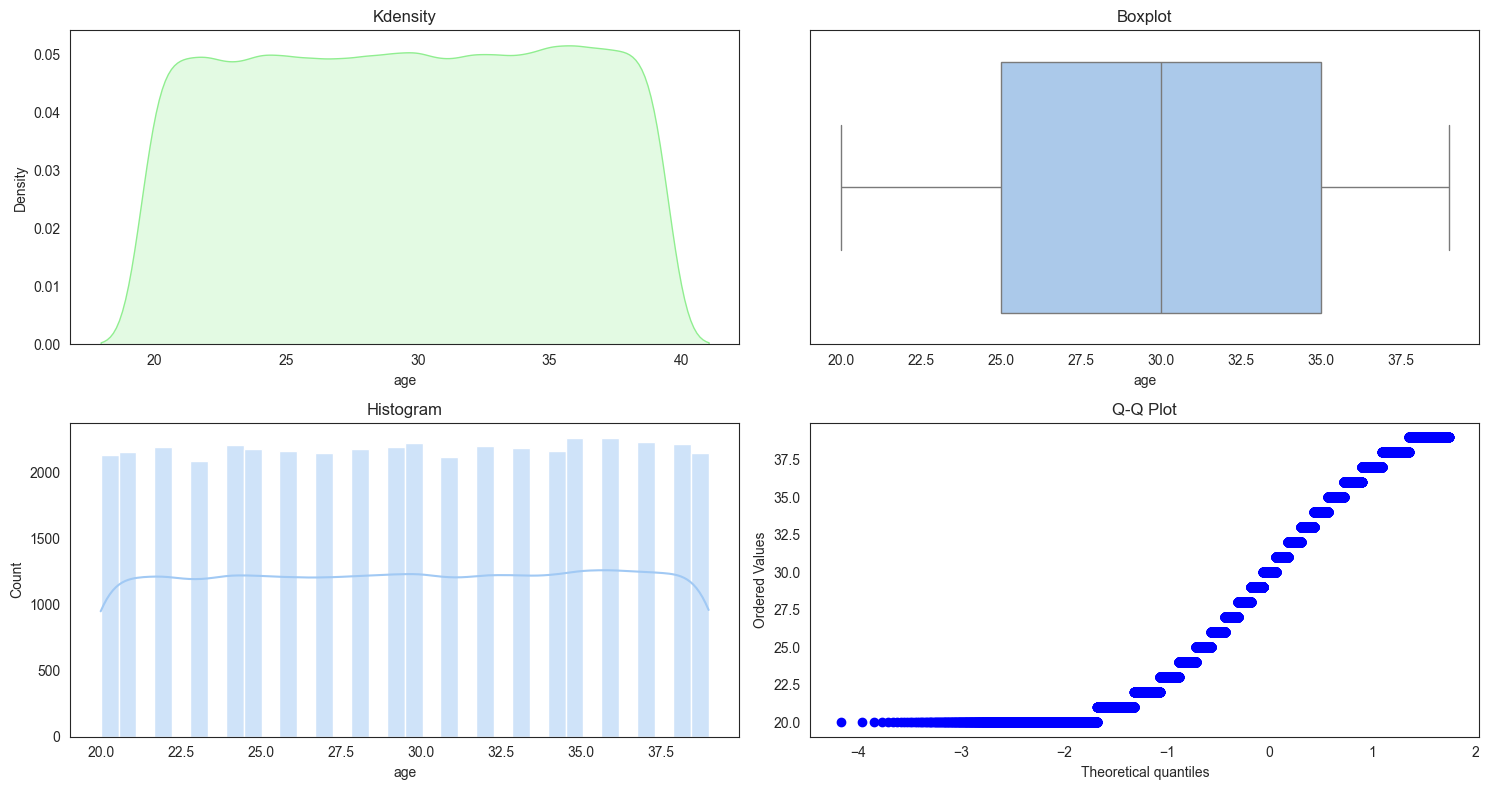

count    43648.000000
mean        29.555008
std          5.761482
min         20.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: age, dtype: float64 

Skewness : -0.014541859592086084 

Data is relativly normally distributed 

------Shapiro wilk test of Normality---------- 

p_value for Shapiro wilk : 0.0000 

Data is not normally distributed 

------Outliers test---------- 

Upper Bound is nan and Lower Bound is nan
Data does not have outliers 

Kurtosis : -1.2085996871450444 

Some Feature Transformation may help 



In [145]:
uni_num('age')

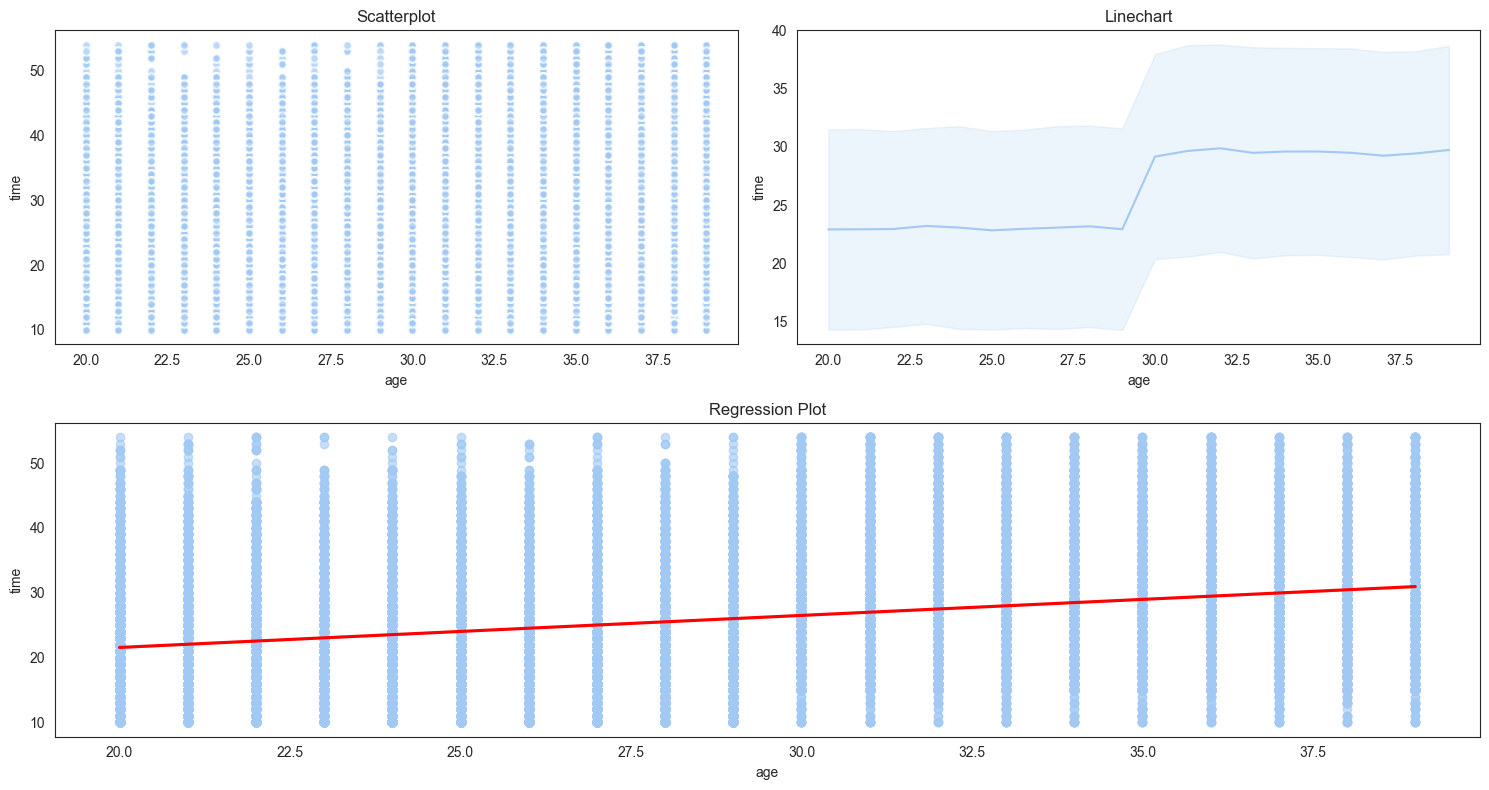

Pearson Correlation test is reliable if both data is normally distributed or their relationship is linear.
pearson coeffient =  0.2972 and p_value =  0.0000
We Reject The Null Hypothesis of No significant Realtionship.
--------------------------------------------------
Spearman Correlation Rank test is reliable without assuming any distribution of the data and their relationship is not linear.
Spearman coeffient =  0.3061 and p_value =  0.0000
We Reject The Null Hypothesis of No significant Realtionship.
--------------------------------------------------
Simple Linear Regresson Test (OLS) 

coefficient =  0.4818 and p_value =  0.0000
A 1 unit change in age is correlated with  0.4818 Unit change in time
R2 value =  0.0883
 8.8344% of total variation in time Can be explained by age
We Reject The Null Hypothesis of No significant Realtionship.


In [146]:
num_num('time','age')

(1) Rider's Age is Uniformly distributed, it does not have any visible impact on the delivery time but statistical test says there is some relation.  
(2) The linechart has a steep piecewise upward break when age is between 28-30 years.

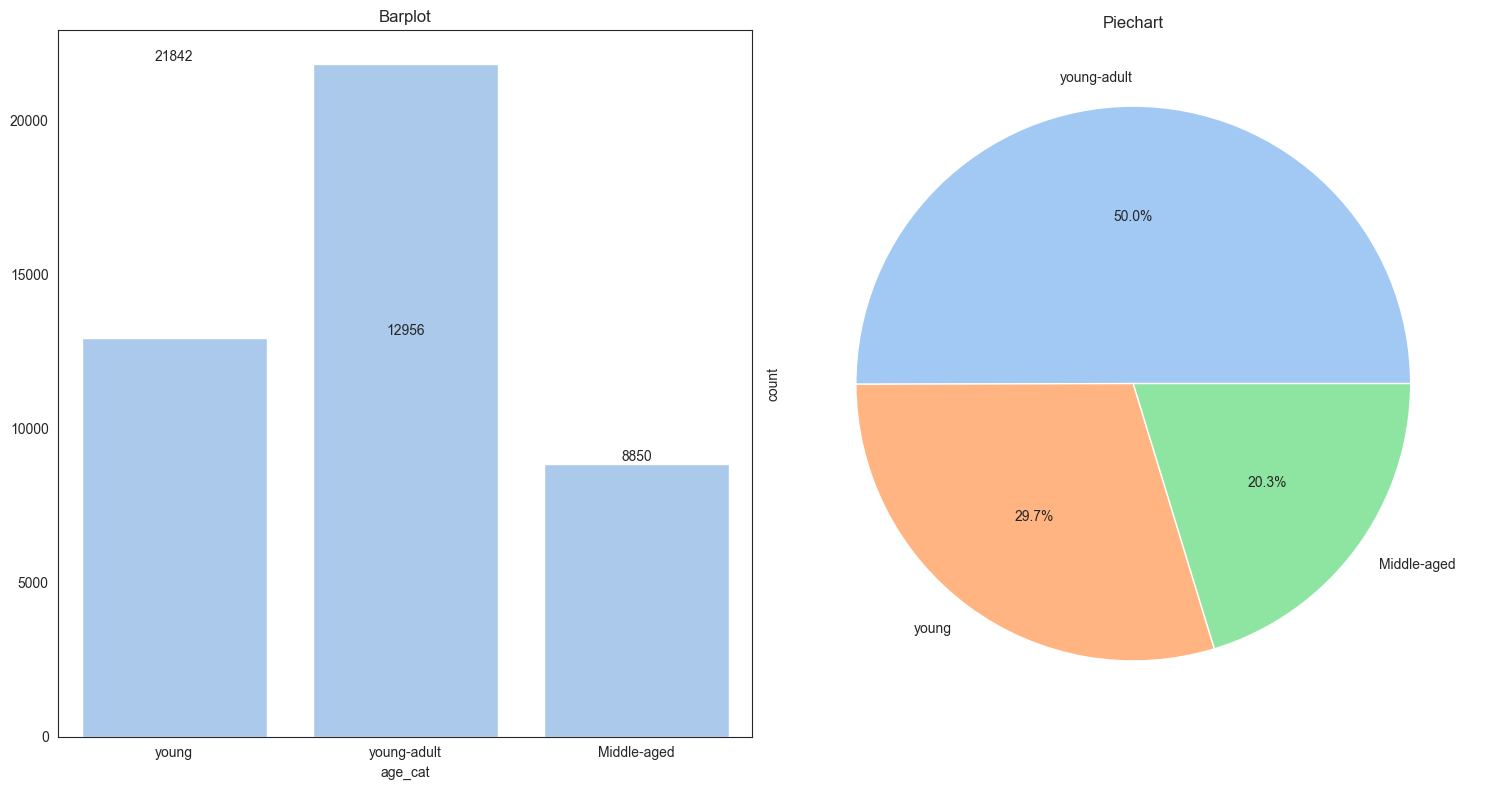

There are 3 unique values in age_cat column 

There are 4.0% missing values in age_cat column 

age_cat
young-adult    21842
young          12956
Middle-aged     8850
Name: count, dtype: int64 



In [147]:
uni_cat('age_cat')

## Ratings

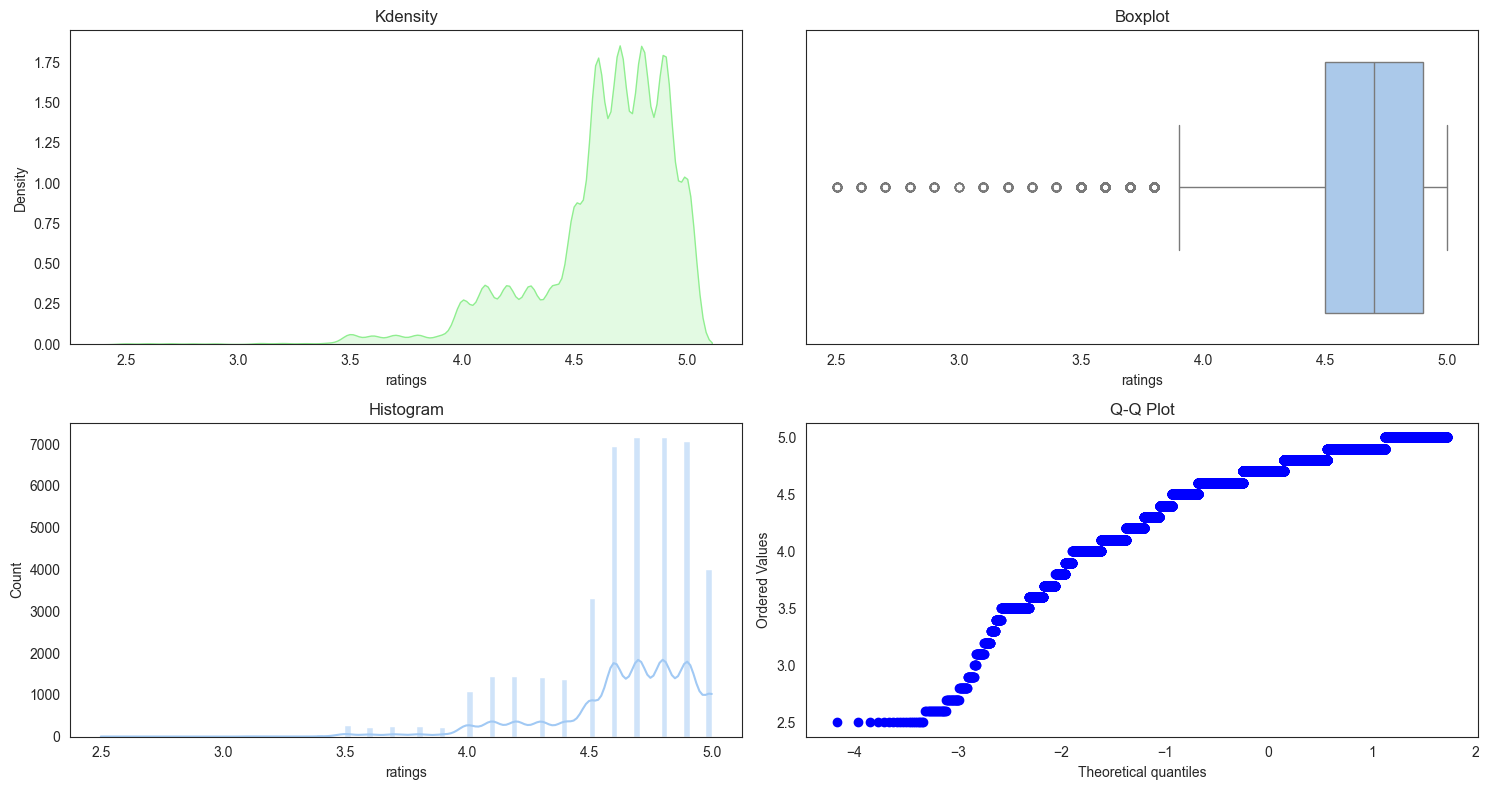

count    43594.000000
mean         4.635287
std          0.313827
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: ratings, dtype: float64 

Skewness : -1.7931177887882856 

Data is not normal,Some Feature Transformation may help 

------Shapiro wilk test of Normality---------- 

p_value for Shapiro wilk : 0.0000 

Data is not normally distributed 

------Outliers test---------- 

Upper Bound is nan and Lower Bound is nan
Data does not have outliers 

Kurtosis : 5.137552745564457 

Some Feature Transformation may help 



In [148]:
uni_num('ratings')

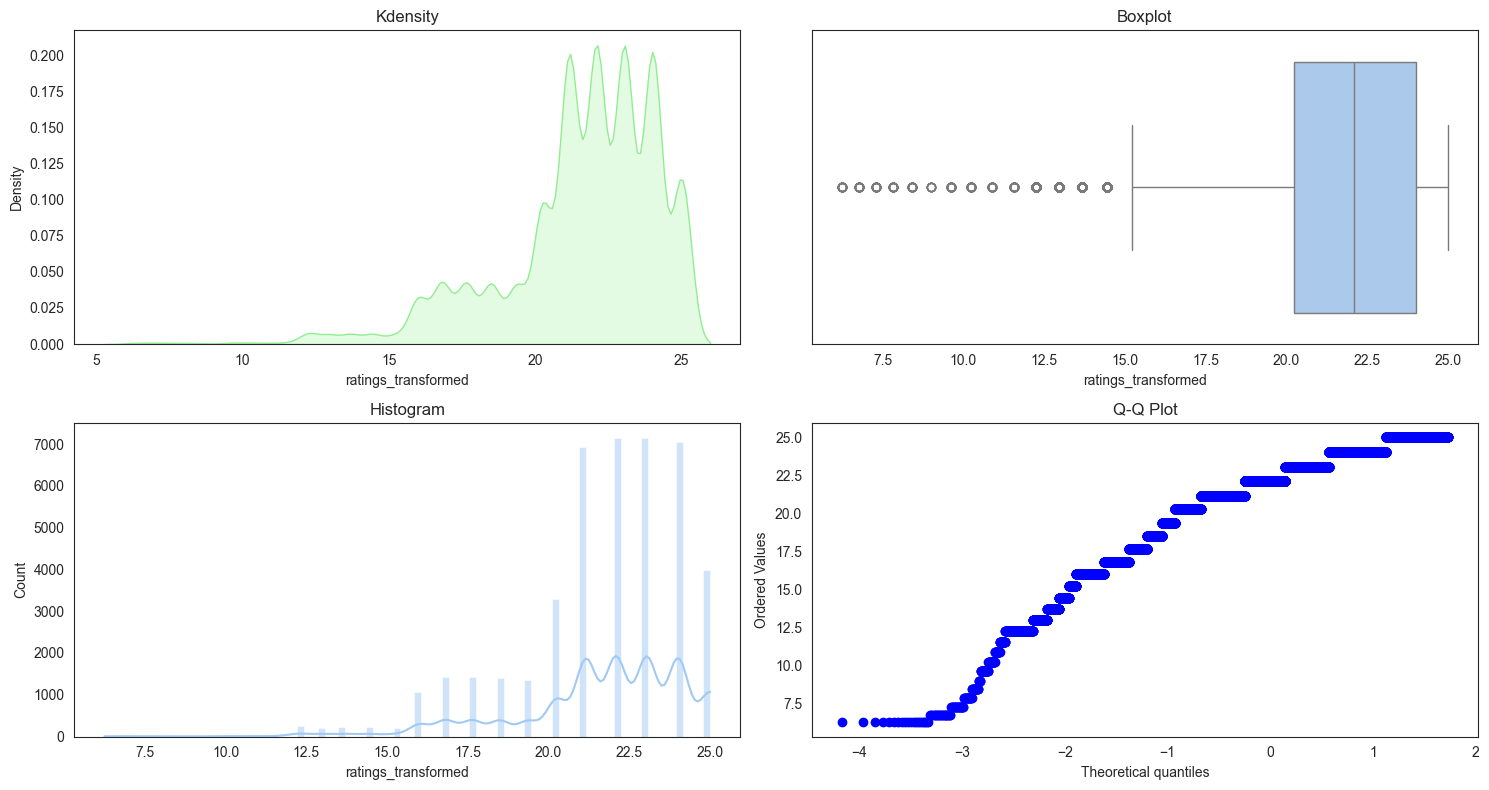

count    43594.000000
mean        21.584370
std          2.739712
min          6.250000
25%         20.250000
50%         22.090000
75%         24.010000
max         25.000000
Name: ratings_transformed, dtype: float64 

Skewness : -1.4061518904122232 

Data is not normal,Some Feature Transformation may help 

------Shapiro wilk test of Normality---------- 

p_value for Shapiro wilk : 0.0000 

Data is not normally distributed 

------Outliers test---------- 

Upper Bound is nan and Lower Bound is nan
Data does not have outliers 

Kurtosis : 2.770065372040051 

Some Feature Transformation may help 



In [149]:
cleaned_df['ratings_transformed'] = np.square(df['ratings'])

uni_num('ratings_transformed')

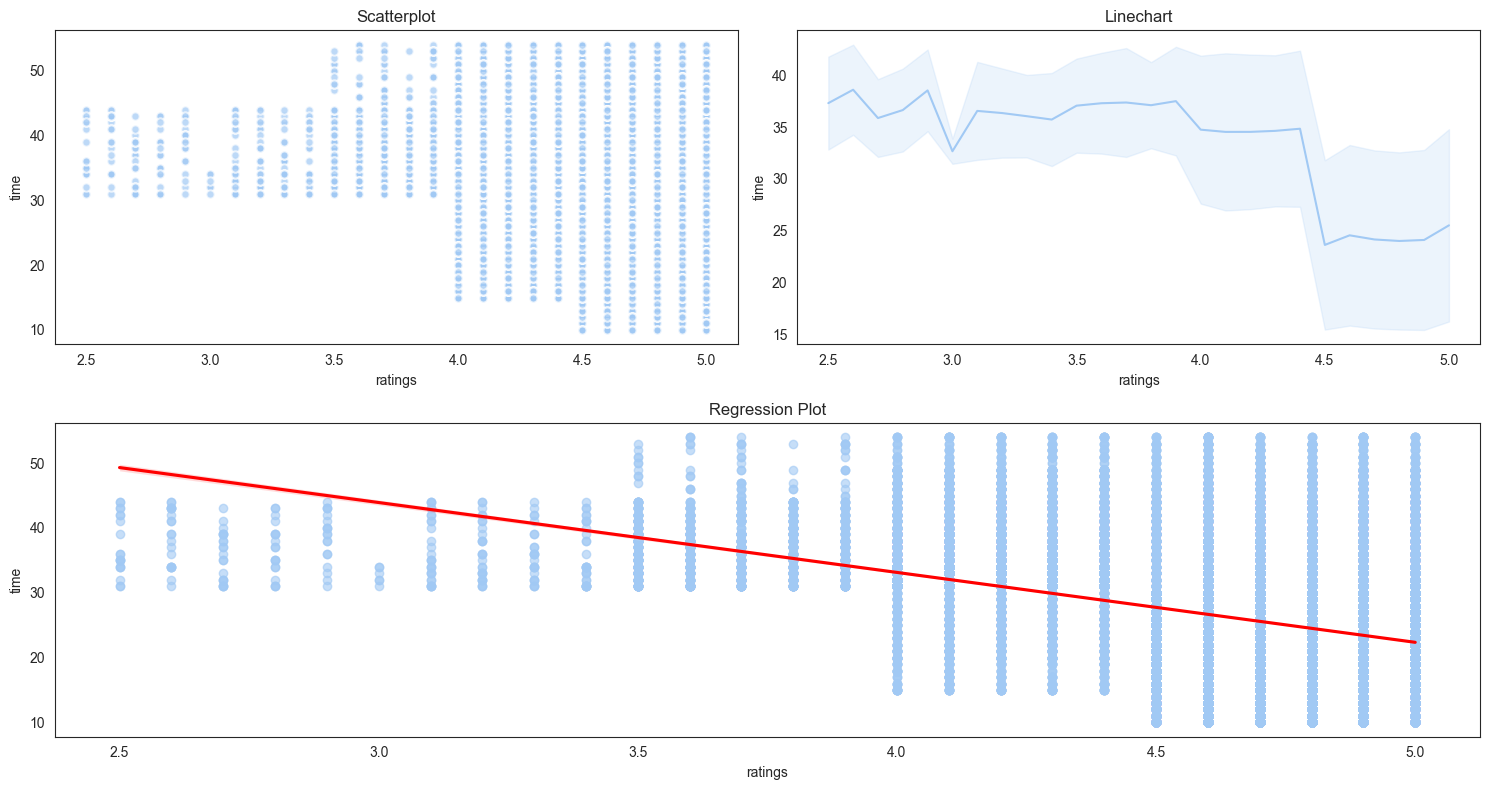

Pearson Correlation test is reliable if both data is normally distributed or their relationship is linear.
pearson coeffient = -0.3611 and p_value =  0.0000
We Reject The Null Hypothesis of No significant Realtionship.
--------------------------------------------------
Spearman Correlation Rank test is reliable without assuming any distribution of the data and their relationship is not linear.
Spearman coeffient = -0.2995 and p_value =  0.0000
We Reject The Null Hypothesis of No significant Realtionship.
--------------------------------------------------
Simple Linear Regresson Test (OLS) 

coefficient = -10.6556 and p_value =  0.0000
A 1 unit change in ratings is correlated with -10.6556 Unit change in time
R2 value =  0.1304
 13.0419% of total variation in time Can be explained by ratings
We Reject The Null Hypothesis of No significant Realtionship.


In [150]:
num_num('time','ratings')

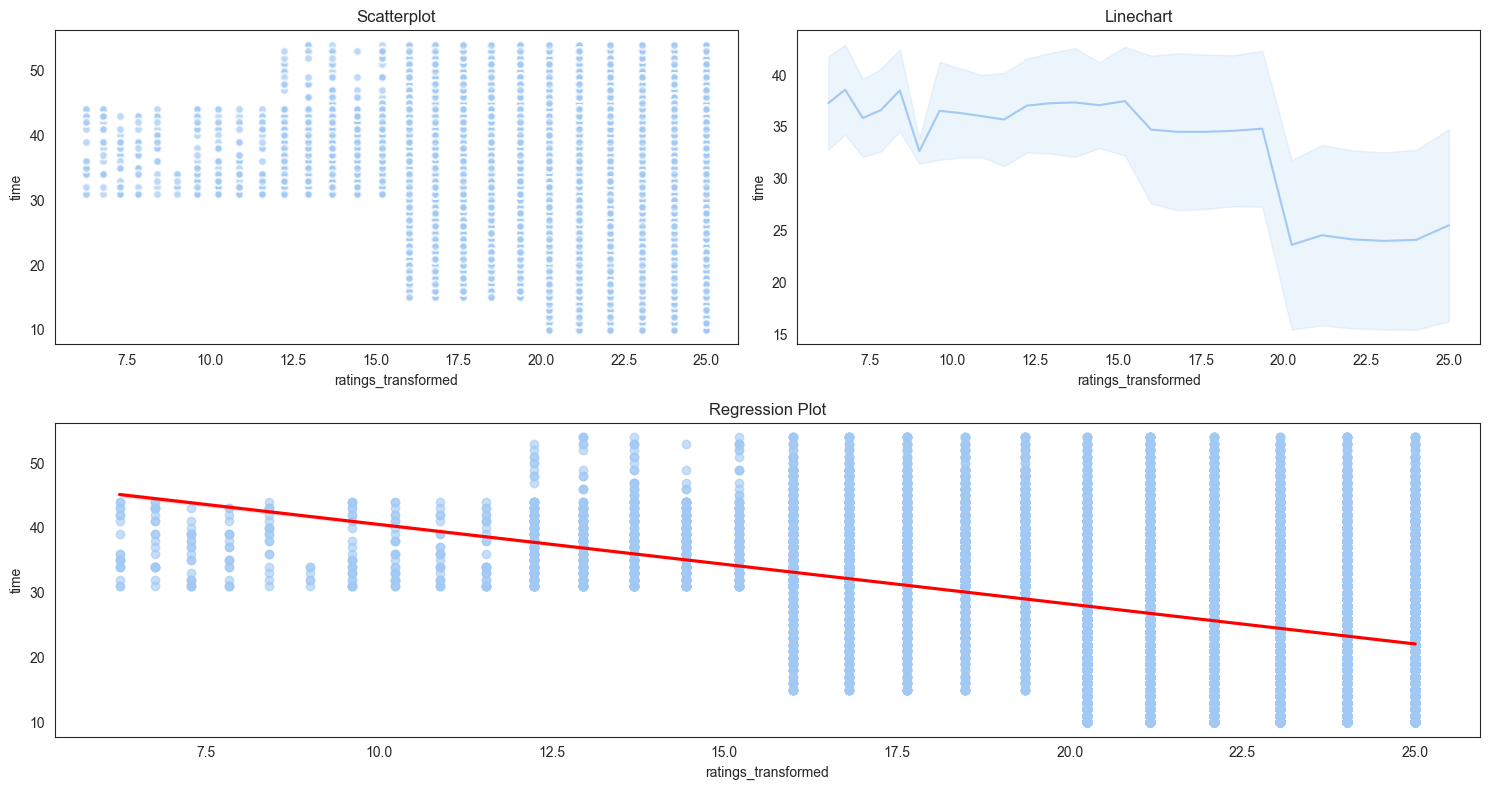

Pearson Correlation test is reliable if both data is normally distributed or their relationship is linear.
pearson coeffient = -0.3599 and p_value =  0.0000
We Reject The Null Hypothesis of No significant Realtionship.
--------------------------------------------------
Spearman Correlation Rank test is reliable without assuming any distribution of the data and their relationship is not linear.
Spearman coeffient = -0.2995 and p_value =  0.0000
We Reject The Null Hypothesis of No significant Realtionship.
--------------------------------------------------
Simple Linear Regresson Test (OLS) 

coefficient = -1.2166 and p_value =  0.0000
A 1 unit change in ratings_transformed is correlated with -1.2166 Unit change in time
R2 value =  0.1295
 12.9516% of total variation in time Can be explained by ratings_transformed
We Reject The Null Hypothesis of No significant Realtionship.


In [151]:
num_num('time','ratings_transformed')

(1) Rating column is left skewed with multimodality and there are some outlier values, We have tried performing feature transformation of square but it did not help.  
(2) still the statistical test says the rating has a significant impact on the delivery time.

p_value : 0.0000 

Atleast one group has mean that is significantly different 



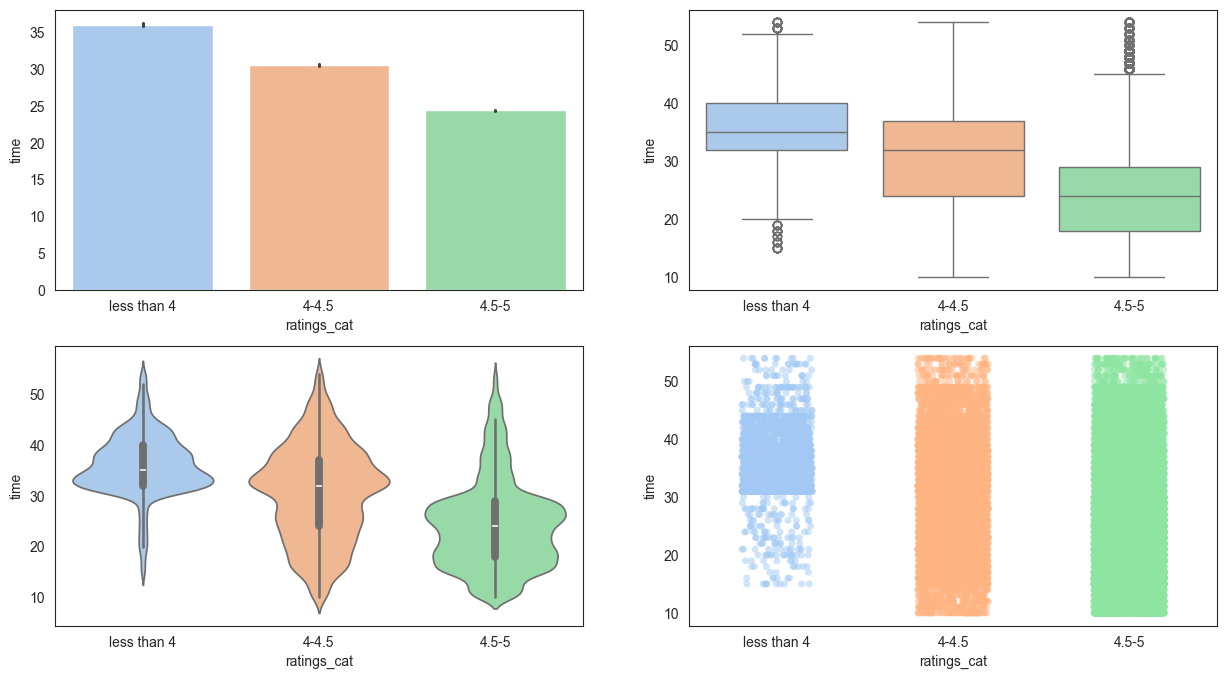

In [152]:
num_cat('time','ratings_cat')

## Traffic

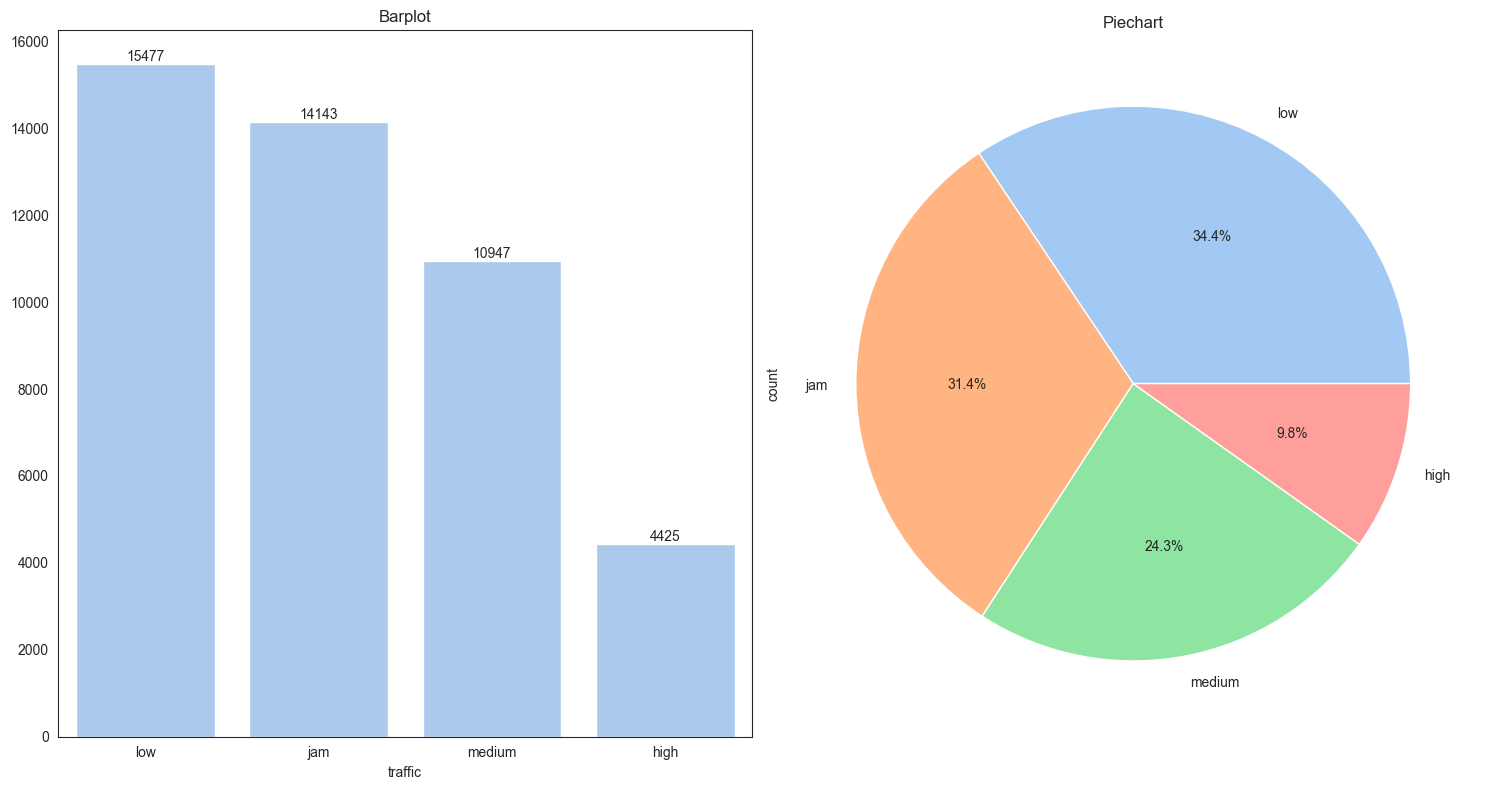

There are 4 unique values in traffic column 

There are 1.0% missing values in traffic column 

traffic
low       15477
jam       14143
medium    10947
high       4425
Name: count, dtype: int64 



In [153]:
uni_cat('traffic')

p_value : 0.0000 

Atleast one group has mean that is significantly different 



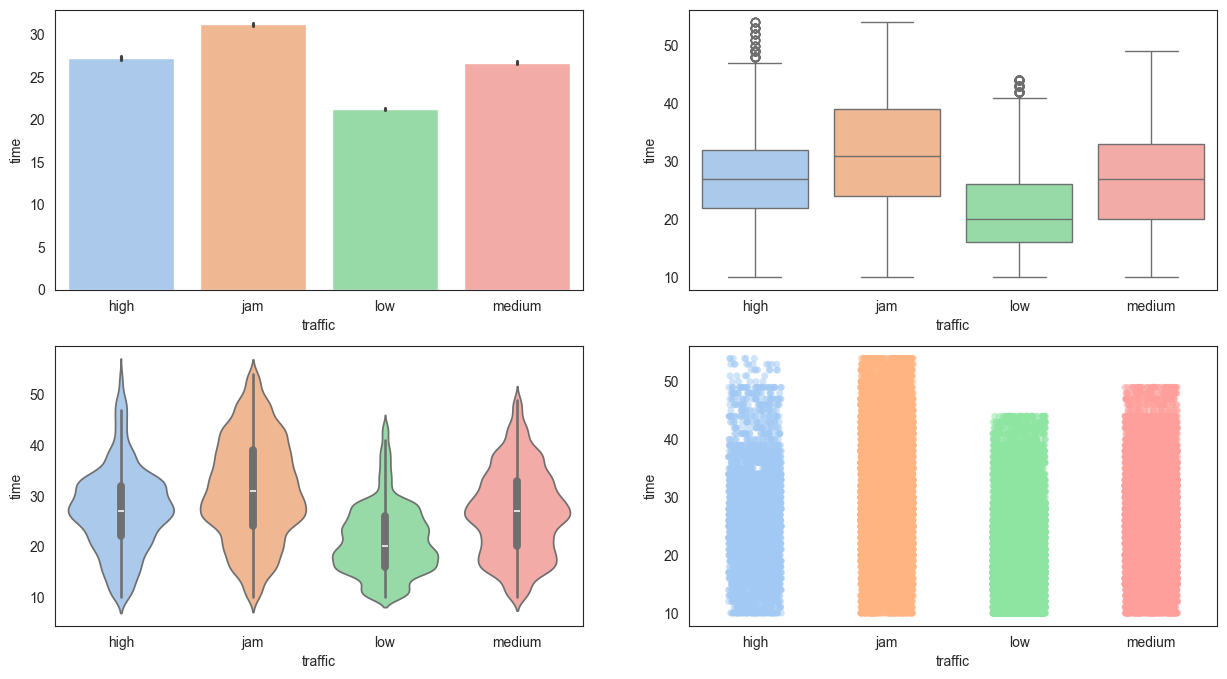

In [154]:
num_cat('time','traffic')

(1) As the mean time for traffic situation is different it is an important feature to predict the delivery time.  
(2) Median Delivery time is highest when there is traffic jam is 30 minutes and lowest when there is no traffic is close to 20 minutes.

## Weather

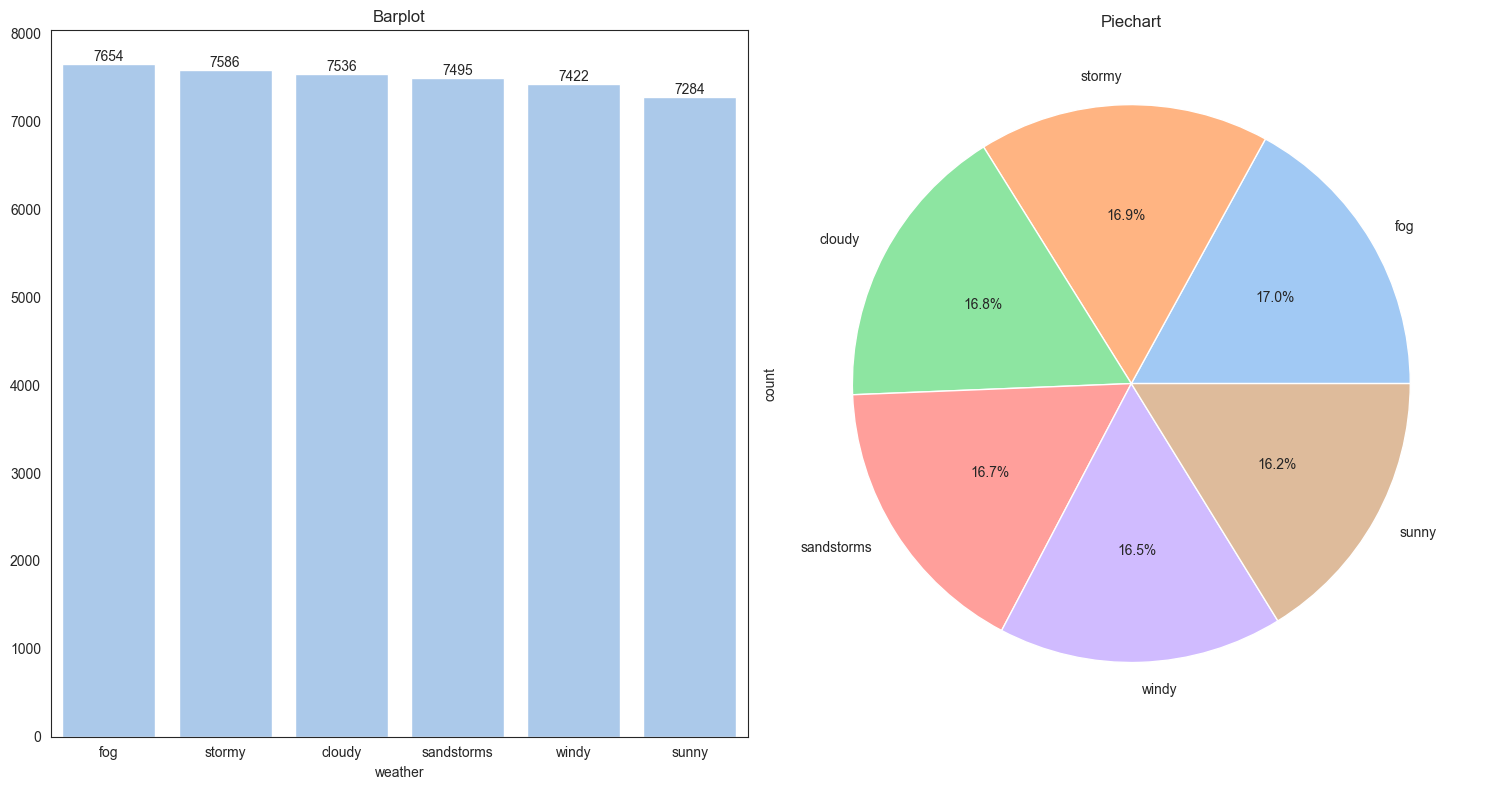

There are 6 unique values in weather column 

There are 1.0% missing values in weather column 

weather
fog           7654
stormy        7586
cloudy        7536
sandstorms    7495
windy         7422
sunny         7284
Name: count, dtype: int64 



In [155]:
uni_cat('weather')

p_value : 0.0000 

Atleast one group has mean that is significantly different 



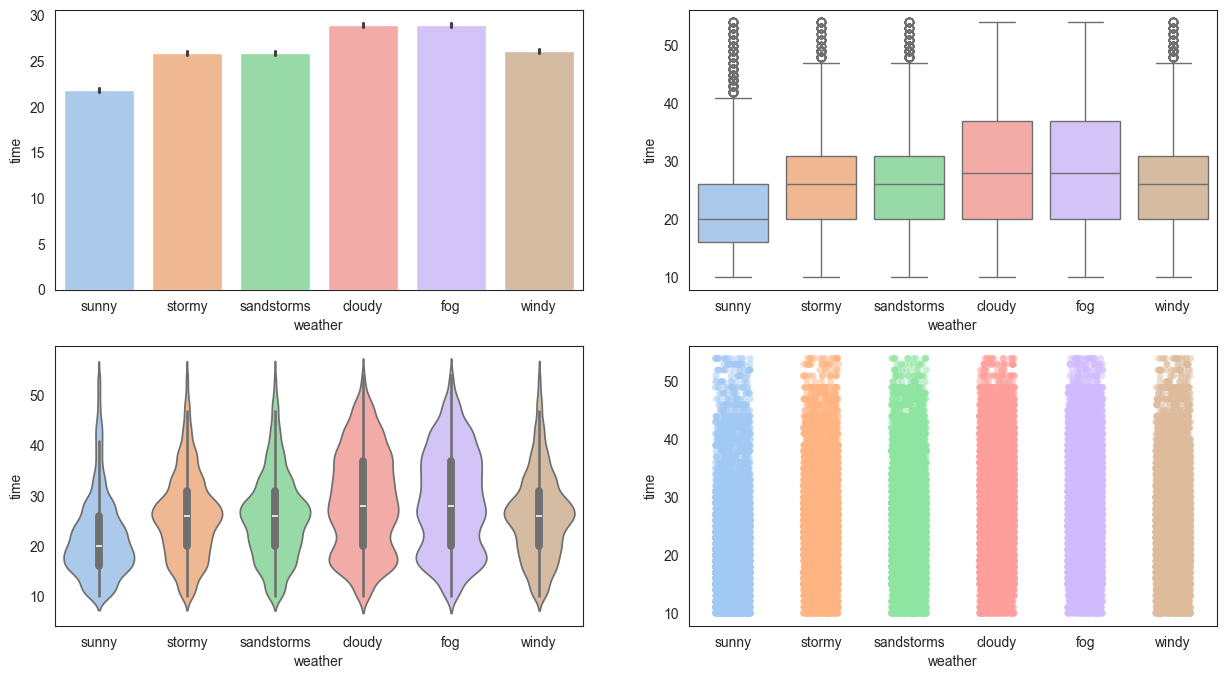

In [156]:
num_cat('time','weather')

(1) Although The Delivery time evenly distributed among all the weather conditions, the anova test says it has a significant impact on the delivery time.  
(2) There are high outliers in the delivery time for sunny, stormy, sandstorm weather conditions.  
(3) Median delivery time for sunny weather is 20 minutes which is the lowest.  
(4) Stormy, Sandstorm and windy weather exhibiting simillar type of distribution. We can group them together as adverse weather conditions.

## vehicle_condition 

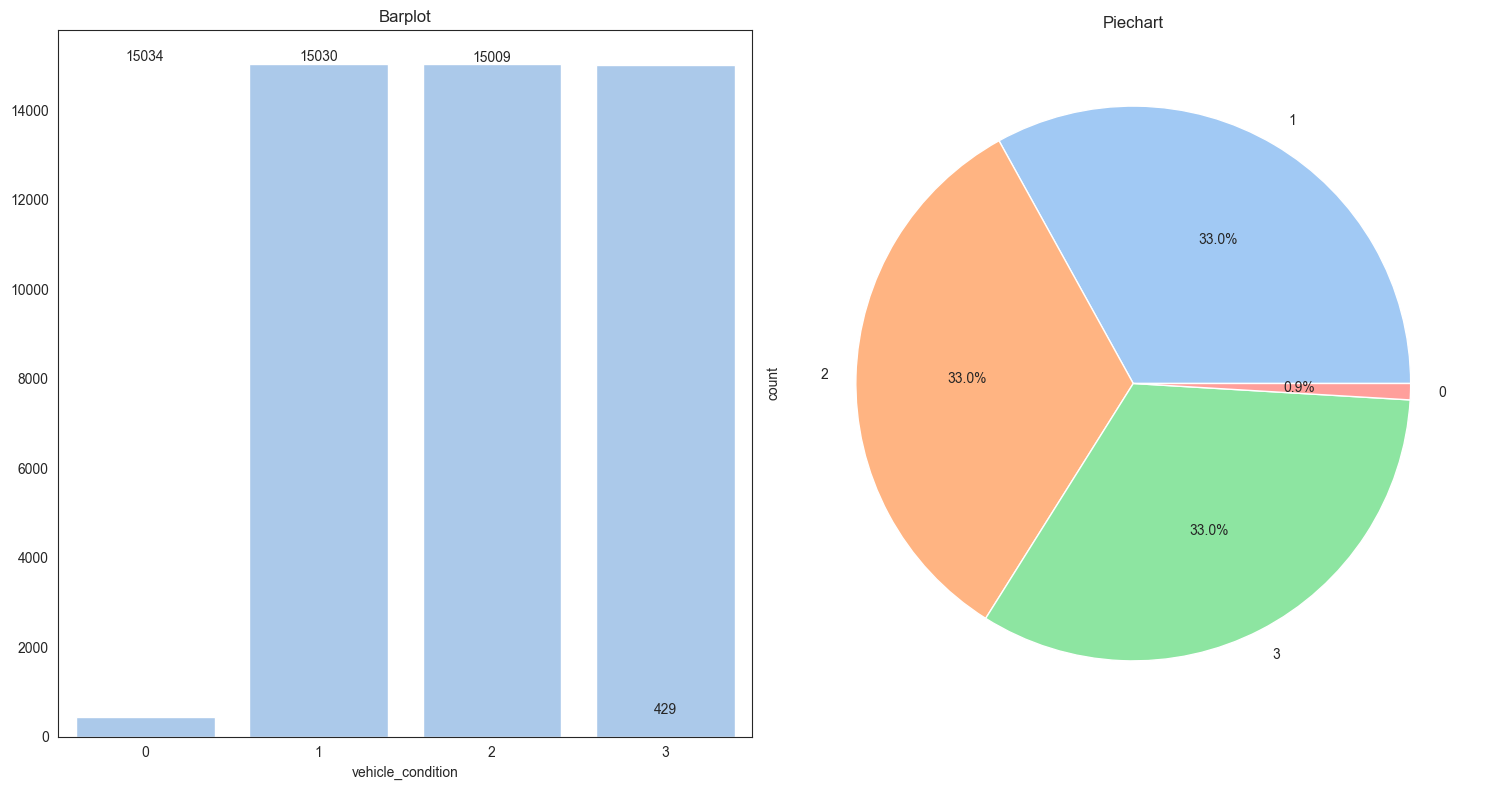

There are 4 unique values in vehicle_condition column 

There are 0.0% missing values in vehicle_condition column 

vehicle_condition
1    15034
2    15030
3    15009
0      429
Name: count, dtype: int64 



In [157]:
uni_cat('vehicle_condition')

p_value : 0.0000 

Atleast one group has mean that is significantly different 



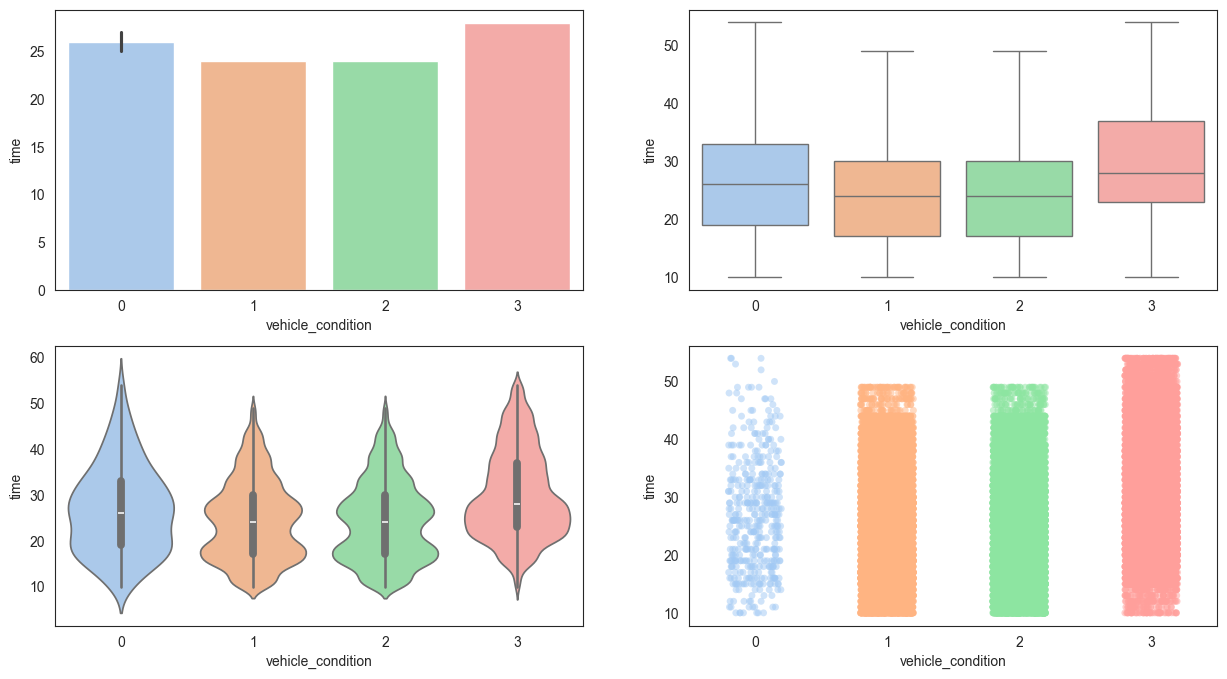

In [158]:
num_cat('time','vehicle_condition',estimator=np.median)

(1) Median time for vehicle condition 3 is 27-28 minutes which is the highest.    
(3) Other vehicle conditions exhibiting simillar type of distribution. 

## Order Type

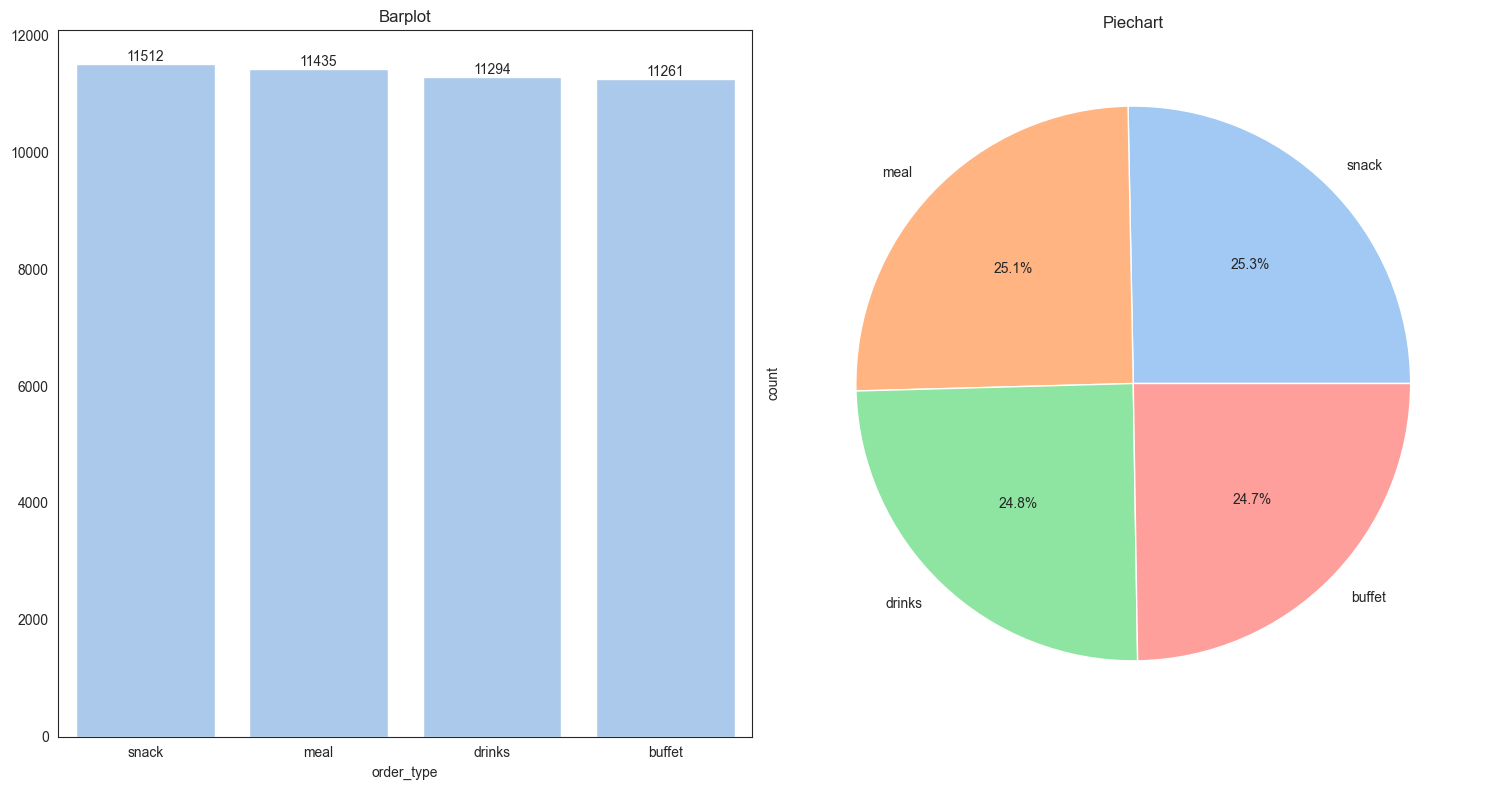

There are 4 unique values in order_type column 

There are 0.0% missing values in order_type column 

order_type
snack     11512
meal      11435
drinks    11294
buffet    11261
Name: count, dtype: int64 



In [159]:
uni_cat('order_type')

p_value : 0.2250 

There is no significant difference between the means of the groups 



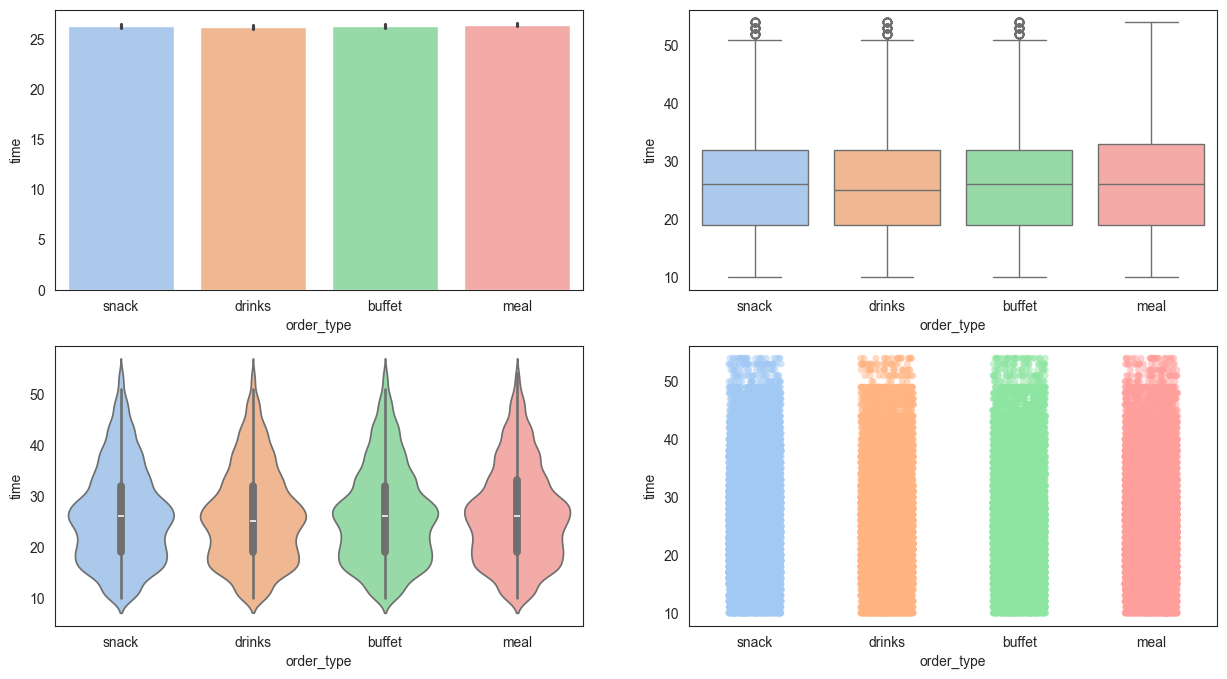

In [160]:
num_cat('time','order_type')

(1) Each order type has simillar distribution and central tendancy.  
(2) There is no impact of order type on the delivery time.

## Vehicle Type

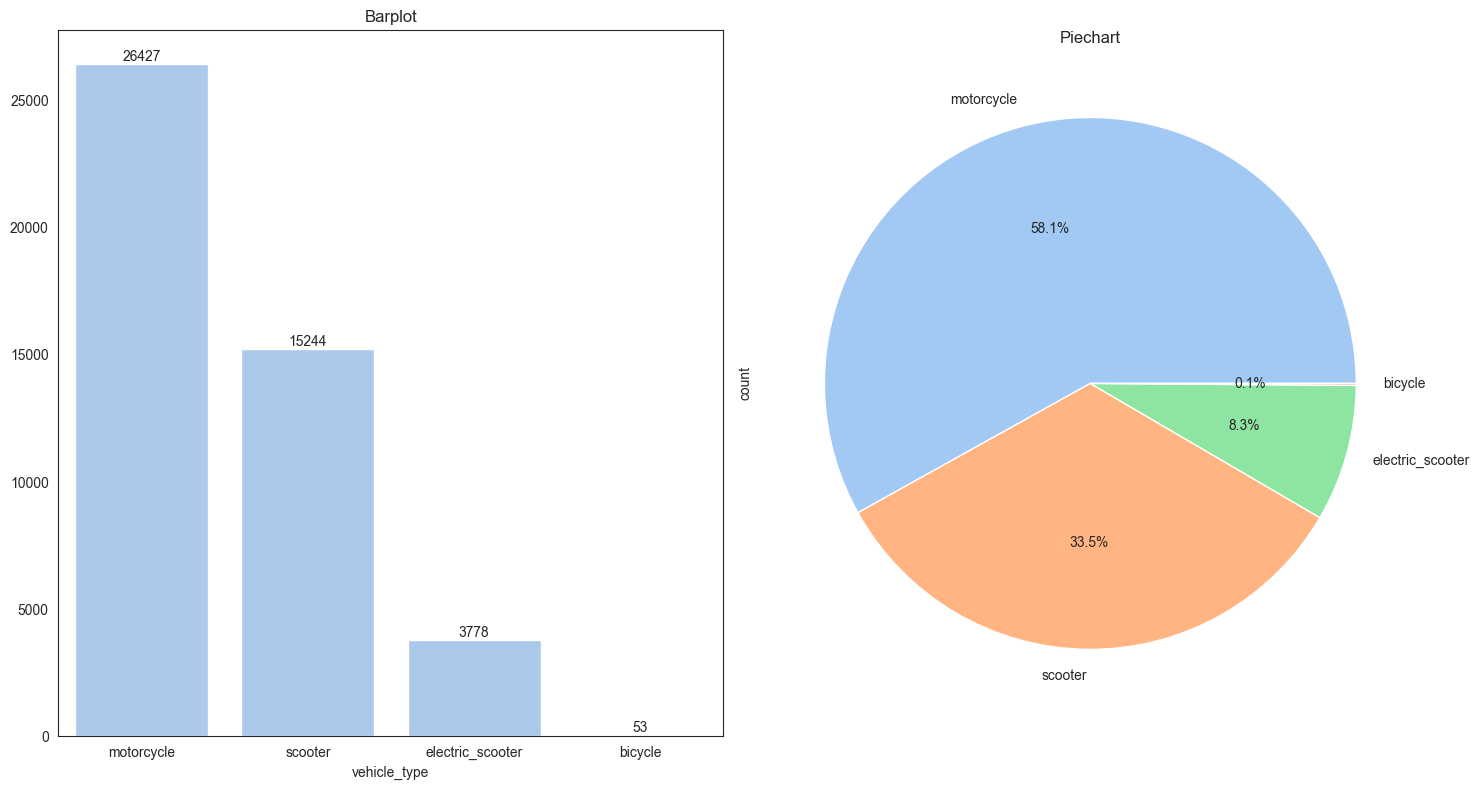

There are 4 unique values in vehicle_type column 

There are 0.0% missing values in vehicle_type column 

vehicle_type
motorcycle          26427
scooter             15244
electric_scooter     3778
bicycle                53
Name: count, dtype: int64 



In [161]:
uni_cat('vehicle_type')

p_value : 0.0000 

Atleast one group has mean that is significantly different 



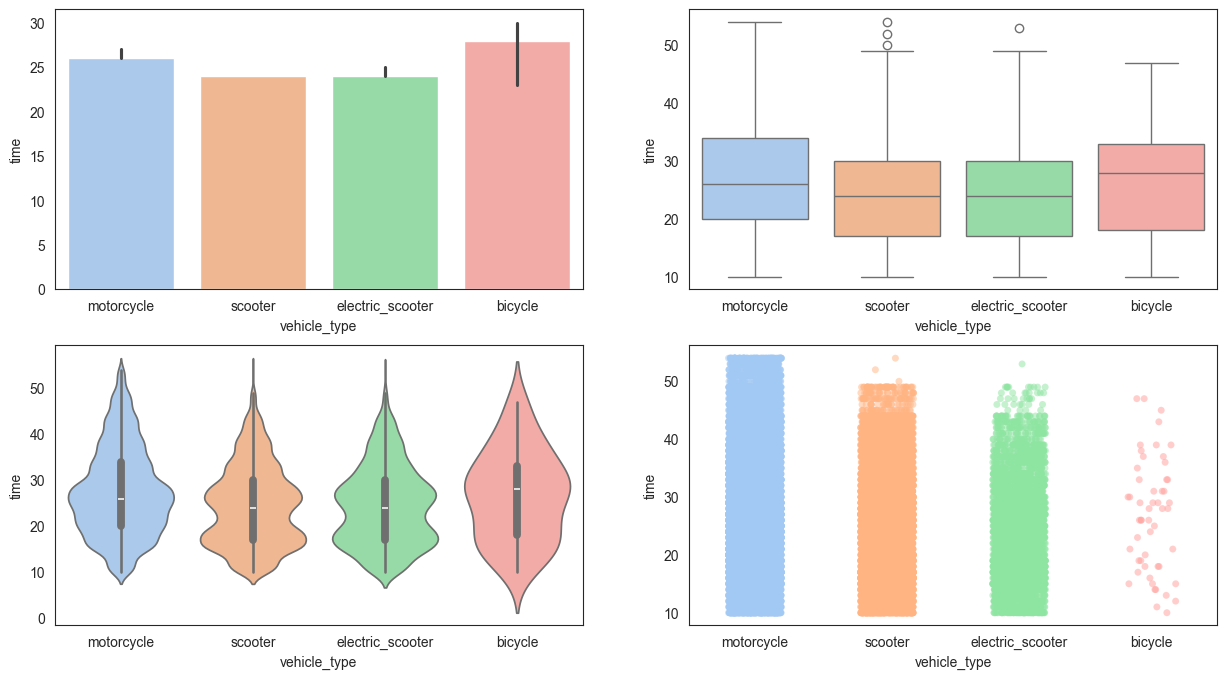

In [162]:
num_cat('time','vehicle_type',estimator=np.median)

(1) Highest Number of vehicle type is Motorcycle with 58% and median delivery time is 27-28 minutes.  
(2) Significant Impact on the delivery time.

## Multiple_Deliveries

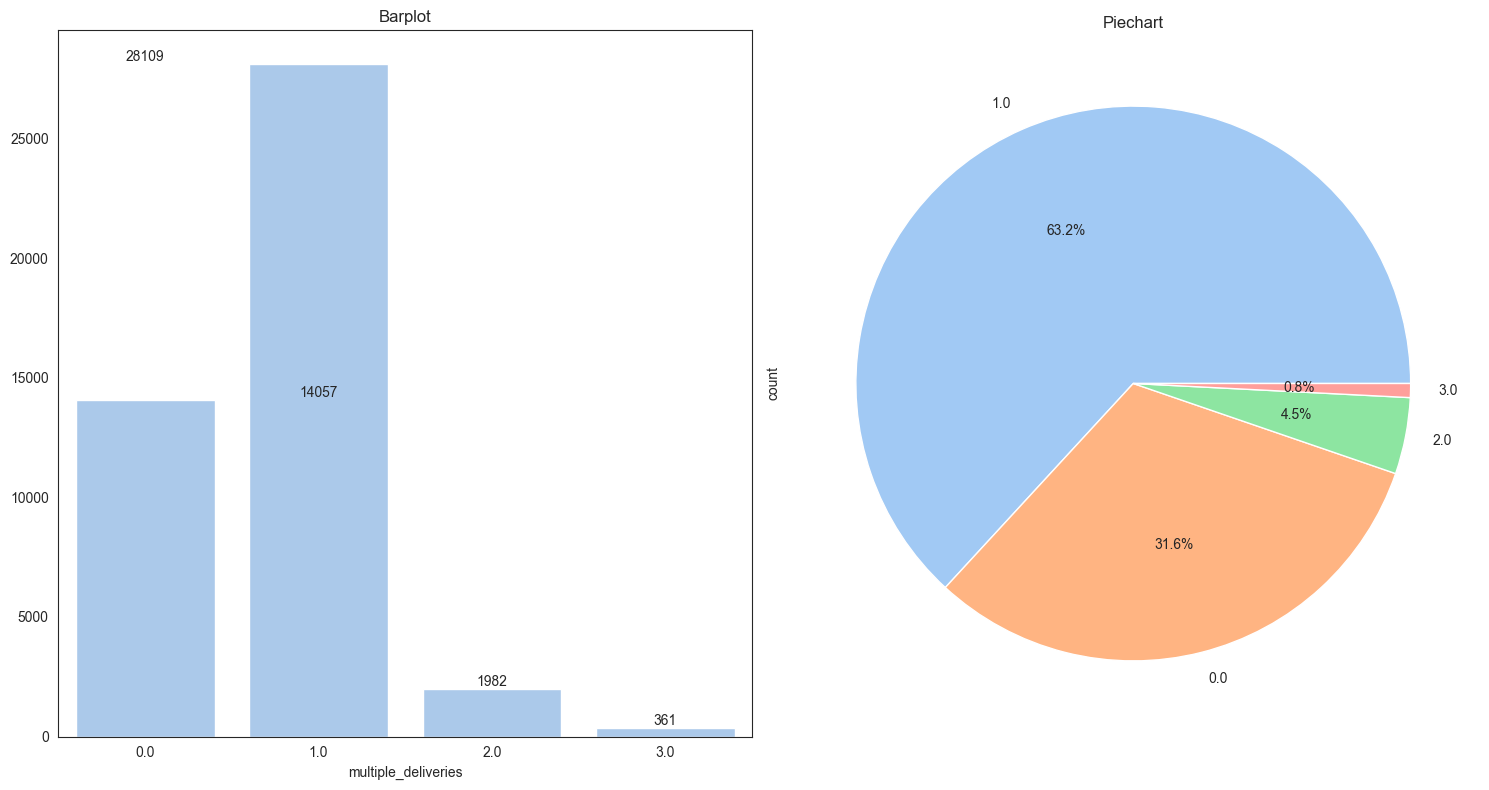

There are 4 unique values in multiple_deliveries column 

There are 2.0% missing values in multiple_deliveries column 

multiple_deliveries
1.0    28109
0.0    14057
2.0     1982
3.0      361
Name: count, dtype: int64 



In [163]:
uni_cat('multiple_deliveries')

p_value : 0.0000 

Atleast one group has mean that is significantly different 



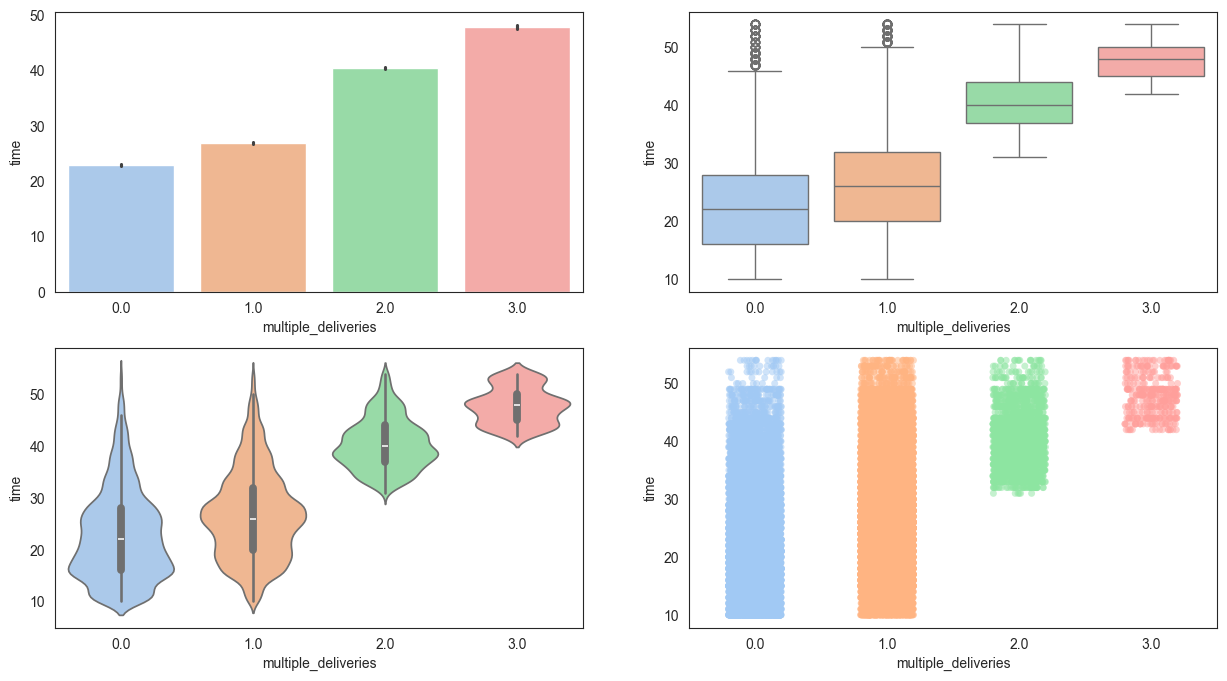

In [164]:
num_cat('time','multiple_deliveries')

(1) Delivery time increases as multiple deliveries increases.  
(2) Although there are not many data available but the time range for 2 and 3 multiple deliveries is 40-50 mintutes.  
(3) we can merge multiple deliveries 2 and 3 together to control their sample size and variance.  
(4) Highest number of deliveries has 1 multiple delivery.

## Festivals

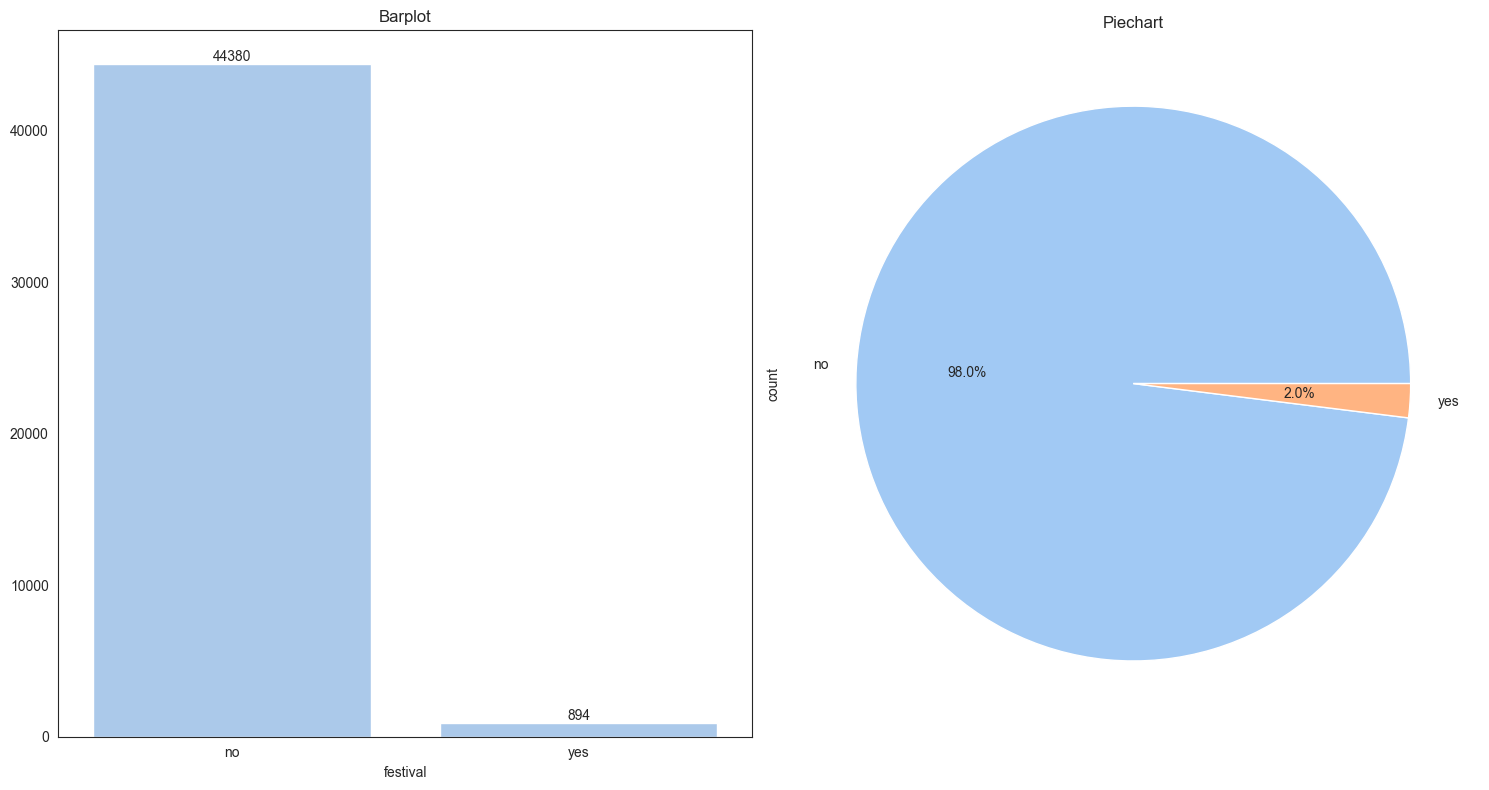

There are 2 unique values in festival column 

There are 1.0% missing values in festival column 

festival
no     44380
yes      894
Name: count, dtype: int64 



In [165]:
uni_cat('festival')

p_value : 0.0000 

There is a significant difference between the means of the groups 



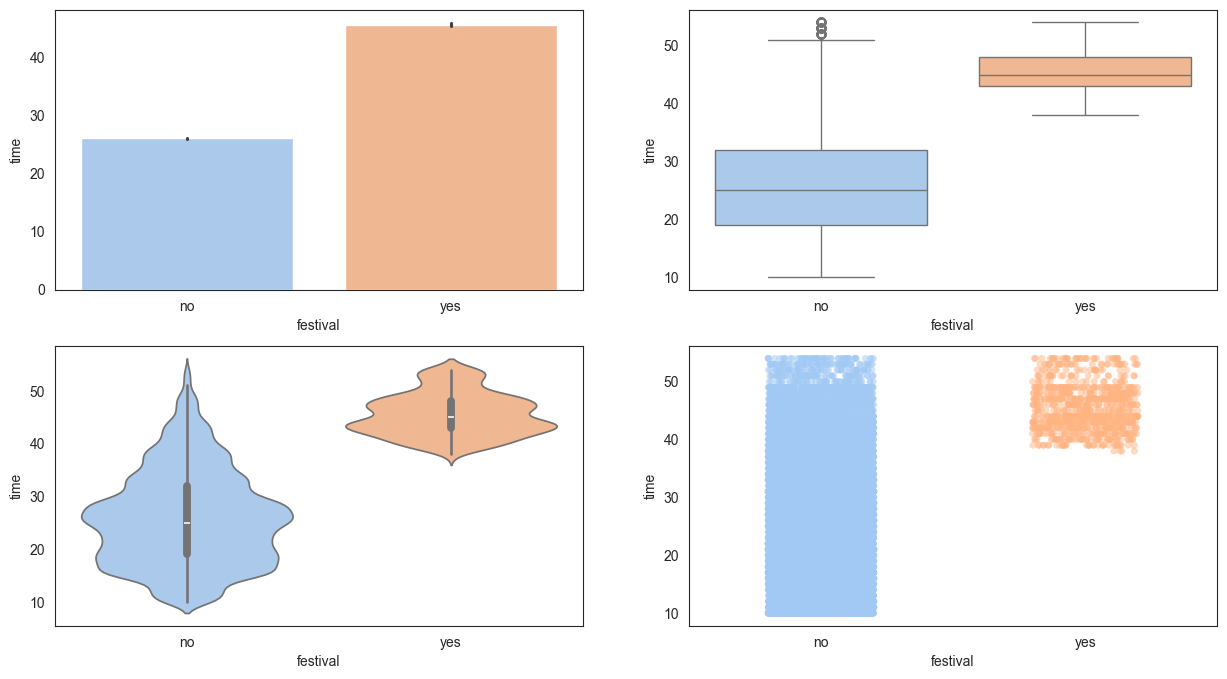

In [166]:
num_cat('time','festival')

(1) During the festivals the median delivery time increases from 25 to 45 minutes.  
(2) Data available for festivals is very low at 2%.

## City Type

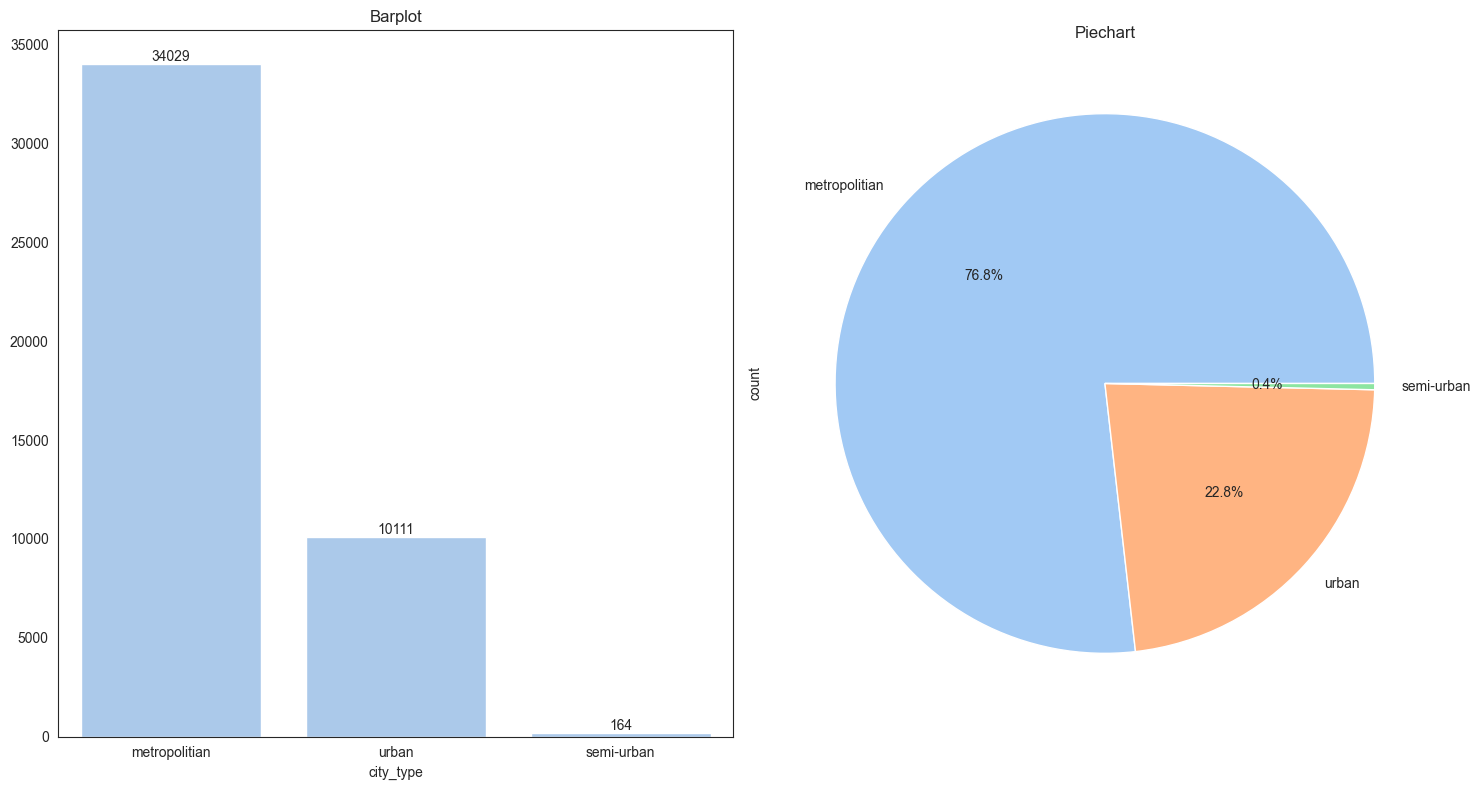

There are 3 unique values in city_type column 

There are 3.0% missing values in city_type column 

city_type
metropolitian    34029
urban            10111
semi-urban         164
Name: count, dtype: int64 



In [167]:
uni_cat('city_type')

p_value : 0.0000 

Atleast one group has mean that is significantly different 



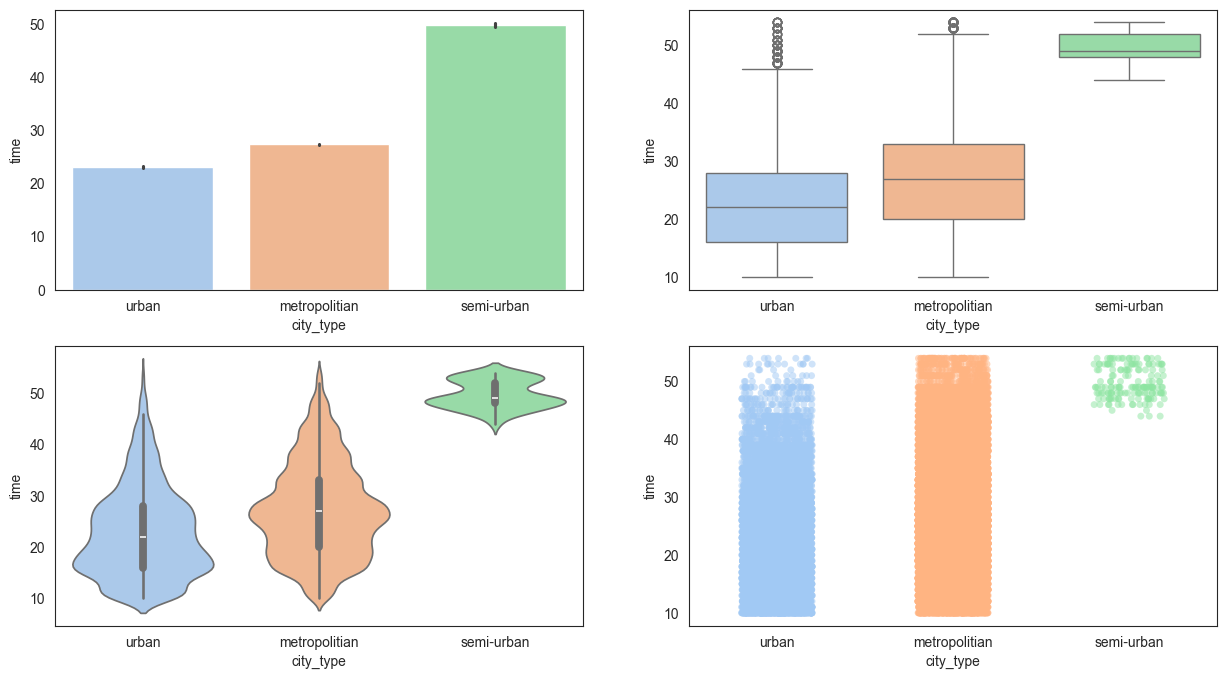

In [168]:
num_cat('time','city_type')

(1) 76% of the delivery is in metropolitan cities with median delivery time of 26-27 minutes.  
(2) Very low data for semi-urban at 0.4%.

## Target Variable Time

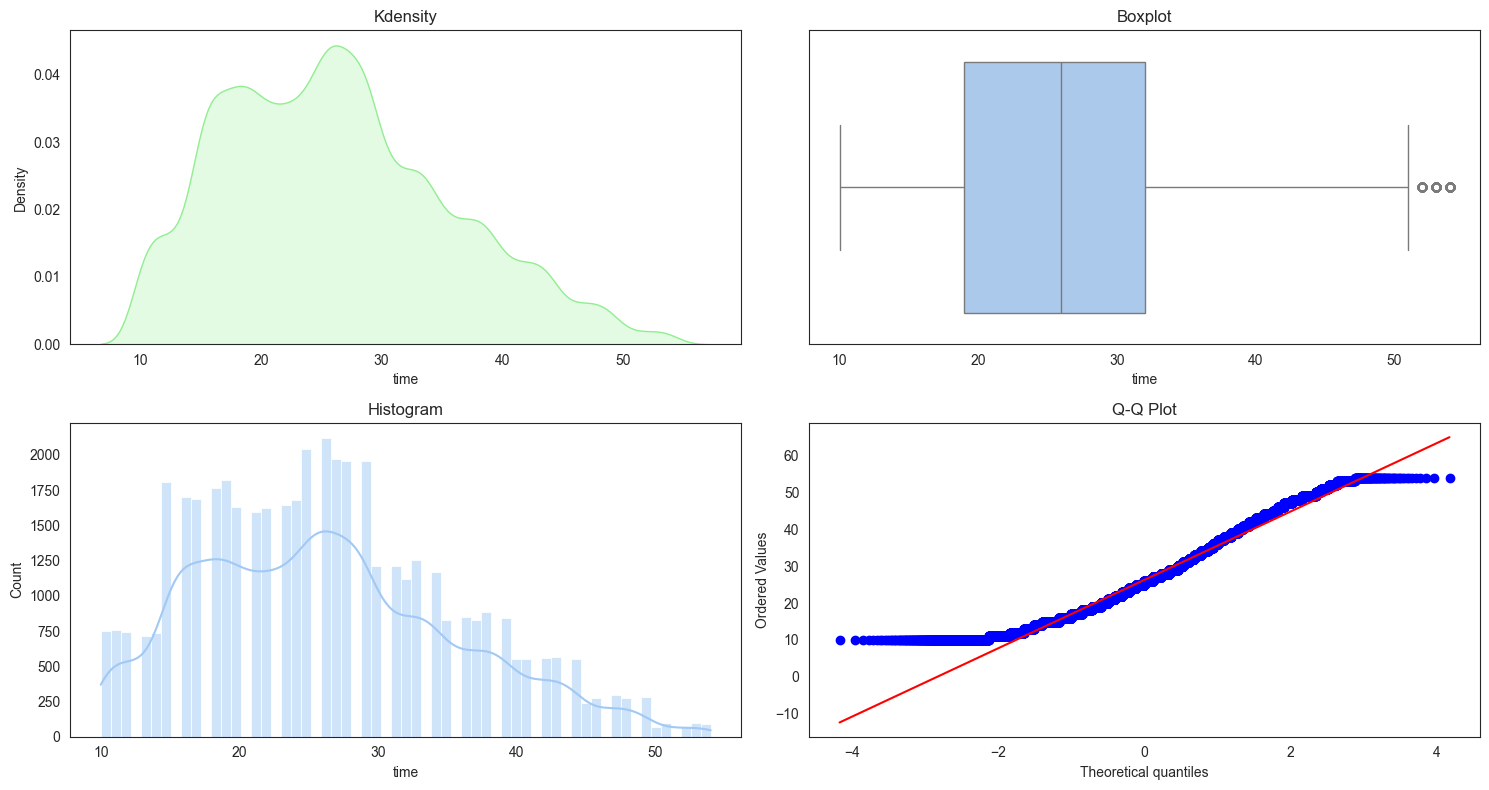

count    45502.000000
mean        26.297591
std          9.386419
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: time, dtype: float64 

Skewness : 0.485582469348261 

Data is relativly normally distributed 

------Shapiro wilk test of Normality---------- 

p_value for Shapiro wilk : 0.0000 

Data is not normally distributed 

------Outliers test---------- 

Upper Bound is 51.5 and Lower Bound is -0.5
Data has outliers 

Kurtosis : -0.3116377537837778 

No extreme outliers present 



In [169]:
uni_num('time')

(1) Mean and Median delivery time is almost simillar at 26 minutes.  
(2) We can see multi modality with 2 peaks at 17-18 and 26-27 minutes.  
(3) skewness is satisfactory at 0.48 and the kurtosis values are also low.    
(4) that's why we can ignore the outliers.

## Distance KM

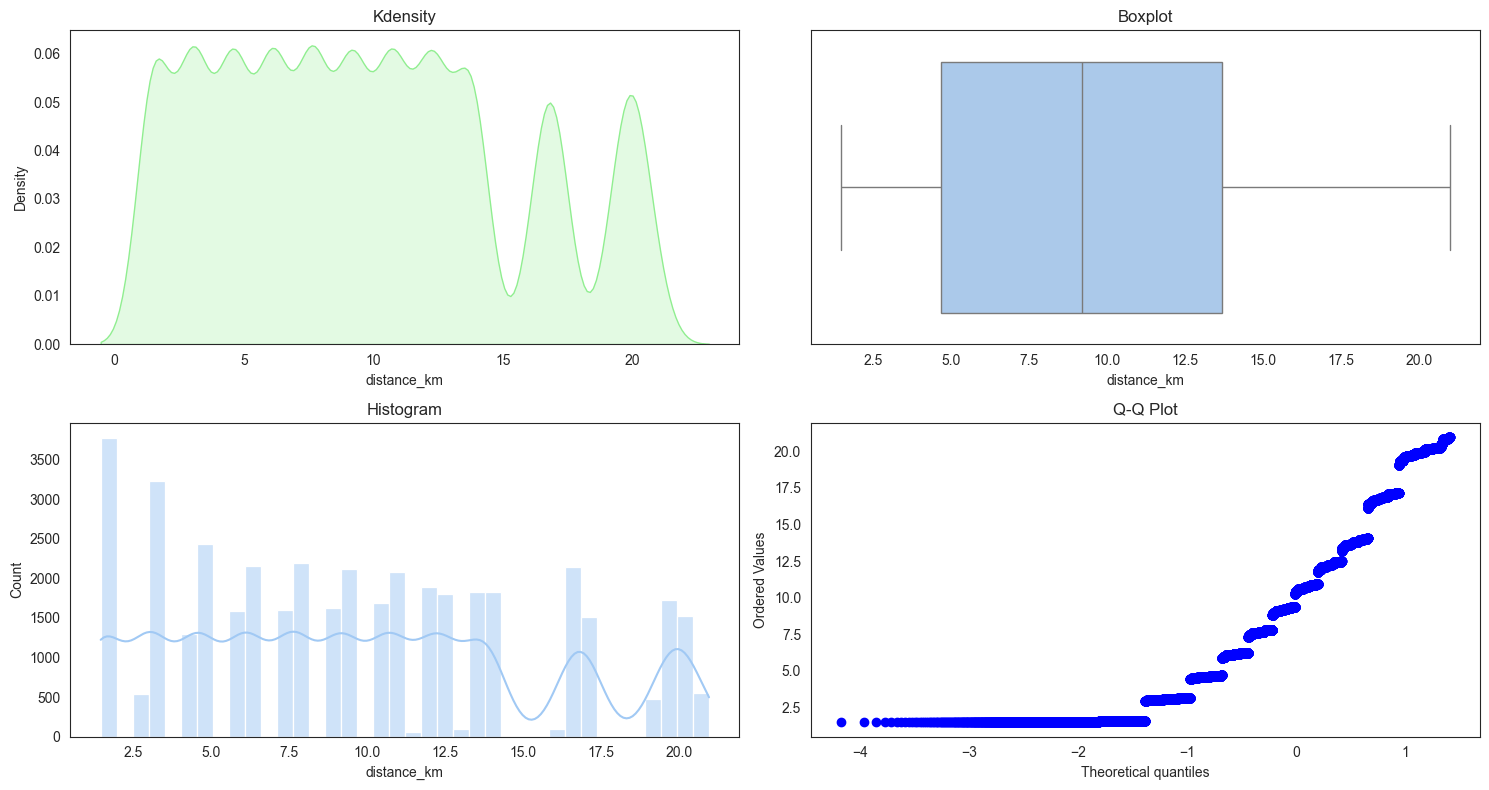

count    41872.000000
mean         9.719272
std          5.602944
min          1.470000
25%          4.660000
50%          9.190000
75%         13.680000
max         20.970000
Name: distance_km, dtype: float64 

Skewness : 0.32497096928519625 

Data is relativly normally distributed 

------Shapiro wilk test of Normality---------- 

p_value for Shapiro wilk : 0.0000 

Data is not normally distributed 

------Outliers test---------- 

Upper Bound is nan and Lower Bound is nan
Data does not have outliers 

Kurtosis : -0.9054558193298532 

No extreme outliers present 



In [170]:
uni_num('distance_km')

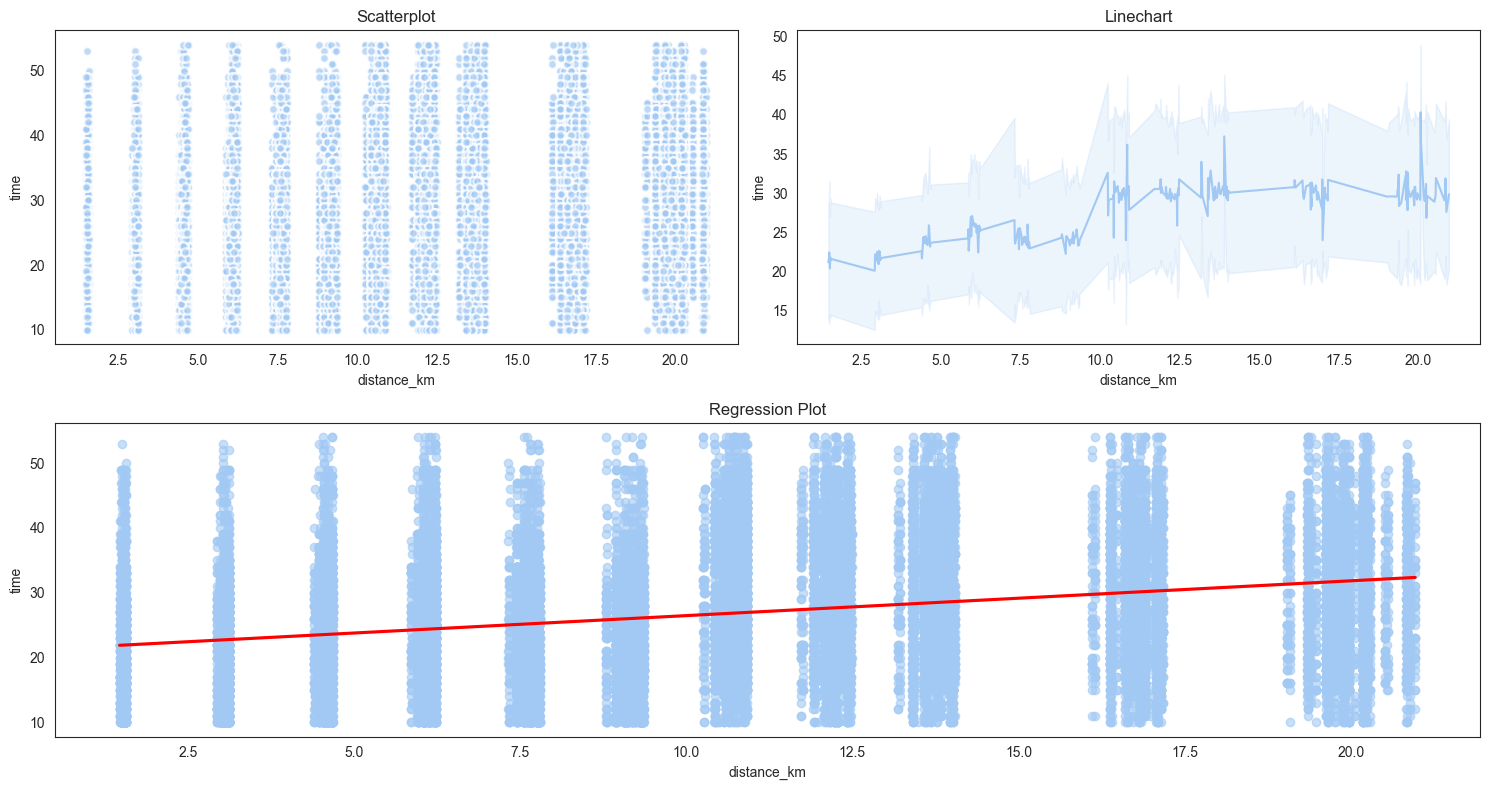

Pearson Correlation test is reliable if both data is normally distributed or their relationship is linear.
pearson coeffient =  0.3242 and p_value =  0.0000
We Reject The Null Hypothesis of No significant Realtionship.
--------------------------------------------------
Spearman Correlation Rank test is reliable without assuming any distribution of the data and their relationship is not linear.
Spearman coeffient =  0.3238 and p_value =  0.0000
We Reject The Null Hypothesis of No significant Realtionship.
--------------------------------------------------
Simple Linear Regresson Test (OLS) 

coefficient =  0.5399 and p_value =  0.0000
A 1 unit change in distance_km is correlated with  0.5399 Unit change in time
R2 value =  0.1051
 10.5076% of total variation in time Can be explained by distance_km
We Reject The Null Hypothesis of No significant Realtionship.


In [171]:
num_num('time','distance_km')

(1) Distance in KM has multimodal distribution.  
(2) Distance is almost distributed as categorically.  
(3) Statistical test says distance has a significant impact on the delivery time.  
(4) Mean distance is 9 Km with Standard Deviation of 5.5 Km.

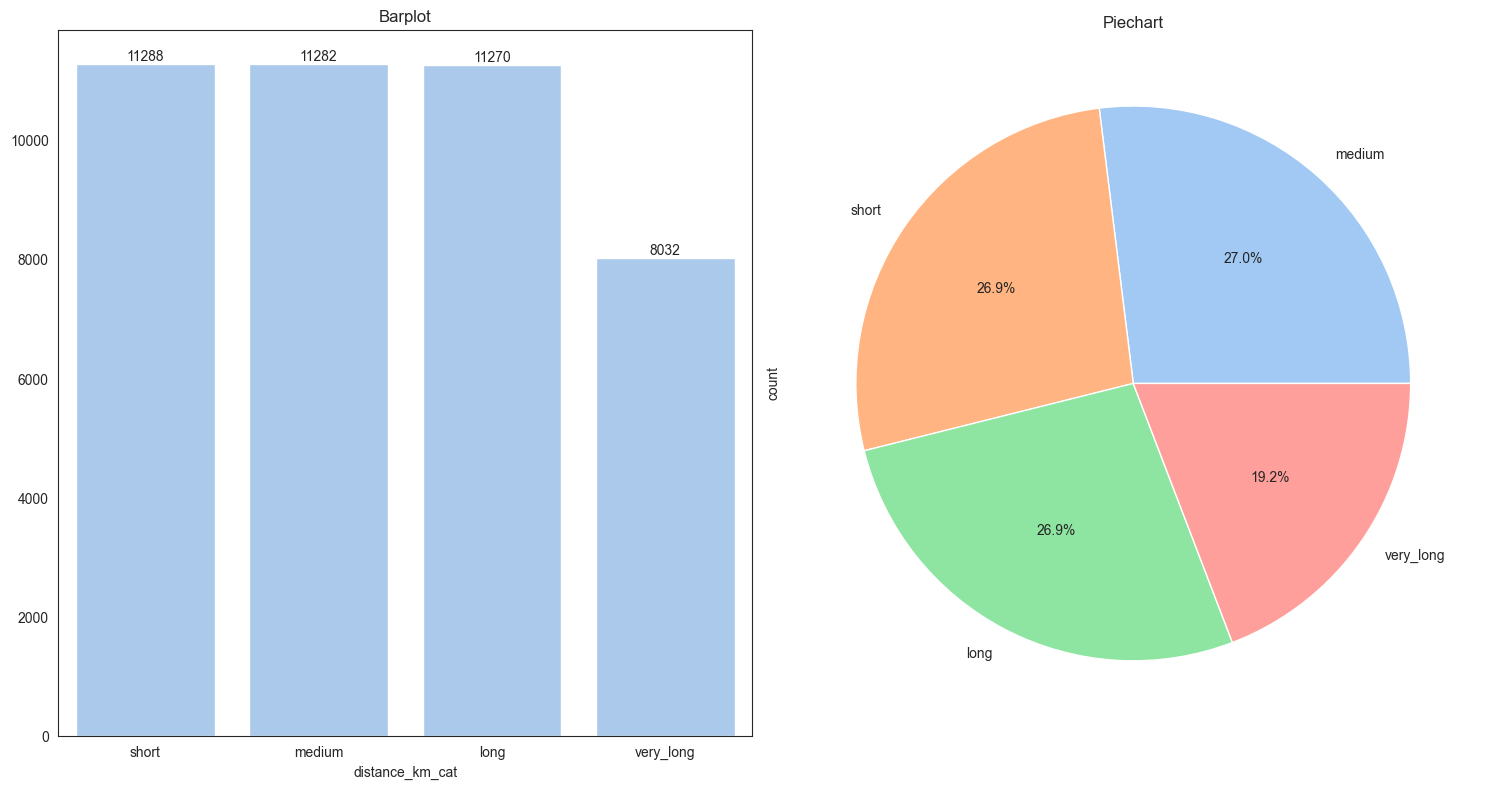

There are 4 unique values in distance_km_cat column 

There are 8.0% missing values in distance_km_cat column 

distance_km_cat
medium       11288
short        11282
long         11270
very_long     8032
Name: count, dtype: int64 



In [172]:
uni_cat('distance_km_cat')

p_value : 0.0000 

Atleast one group has mean that is significantly different 



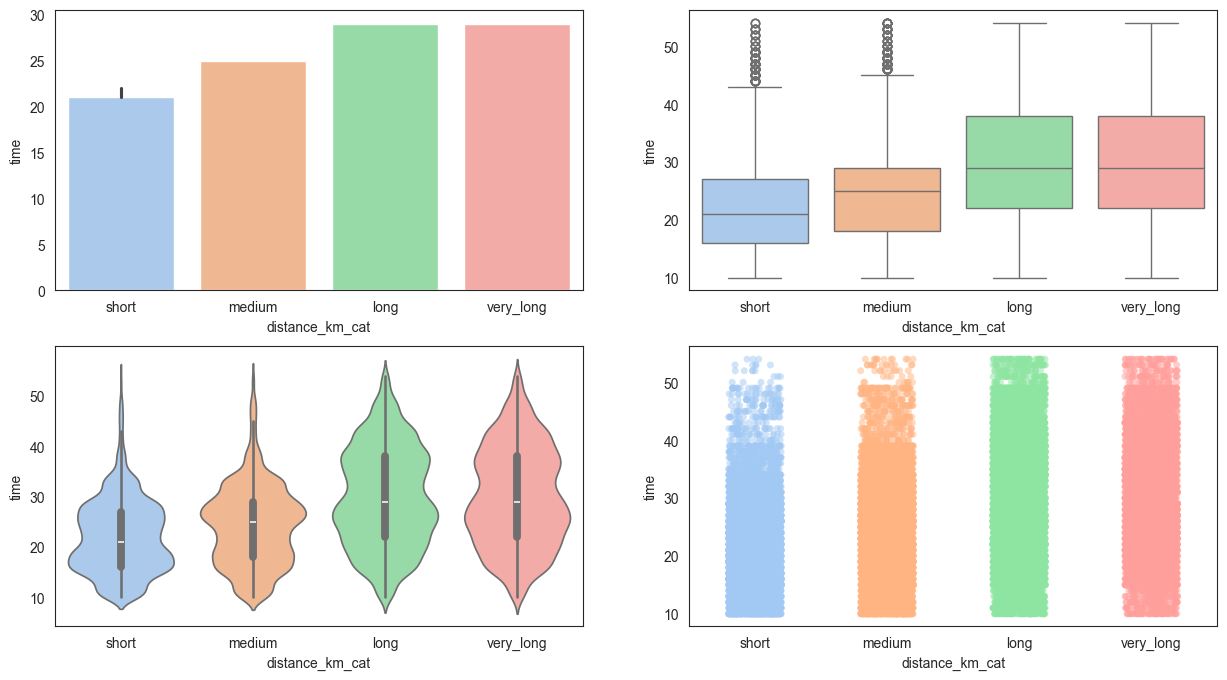

In [173]:
num_cat('time','distance_km_cat',estimator=np.median)

(1) Short and Medium distance has lower median delivery time.

# Day

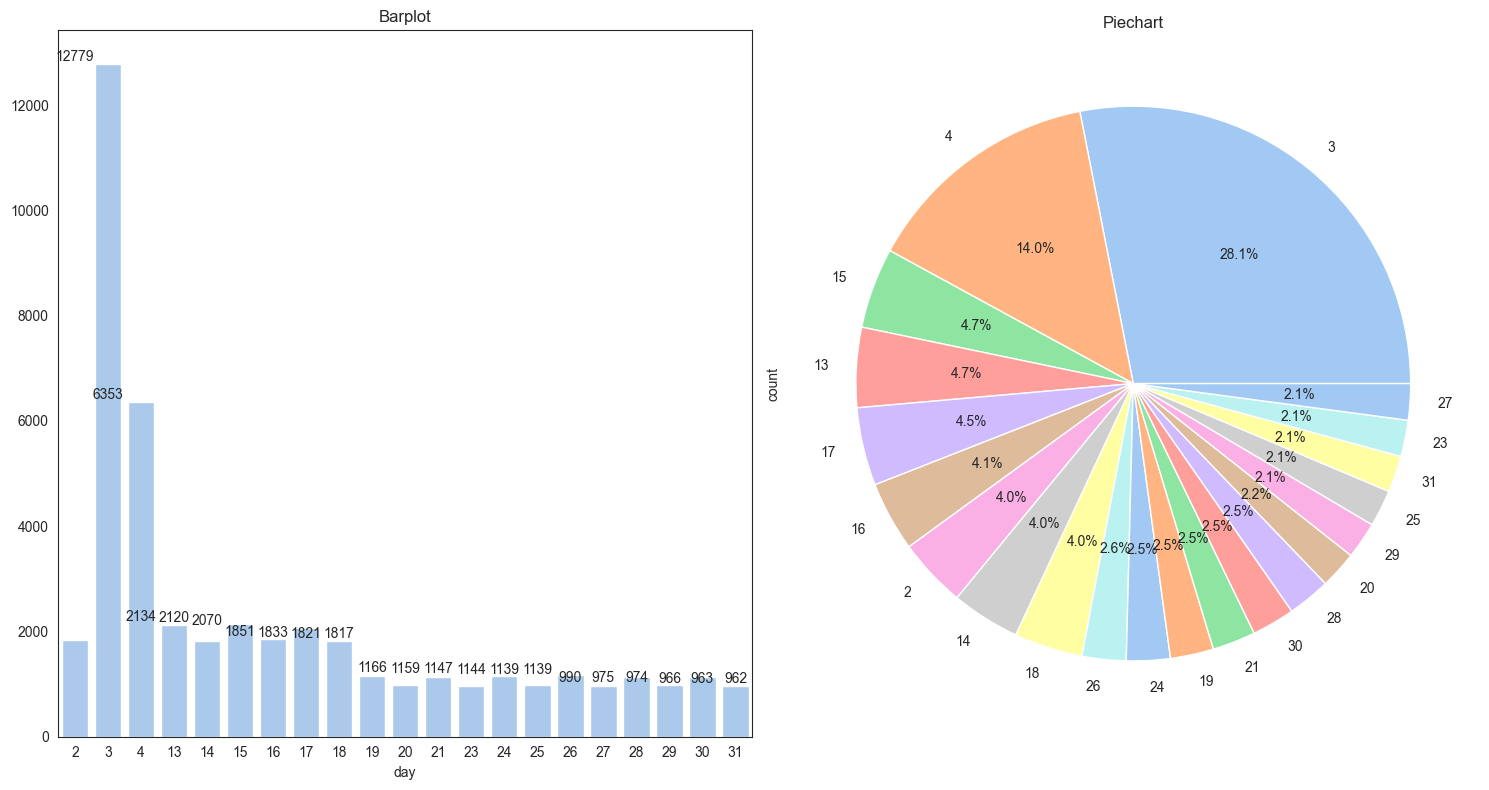

There are 21 unique values in day column 

There are 0.0% missing values in day column 

day
3     12779
4      6353
15     2134
13     2120
17     2070
16     1851
2      1833
14     1821
18     1817
26     1166
24     1159
19     1147
21     1144
30     1139
28     1139
20      990
29      975
25      974
31      966
23      963
27      962
Name: count, dtype: int64 



In [174]:
uni_cat('day')

p_value : 0.0000 

Atleast one group has mean that is significantly different 



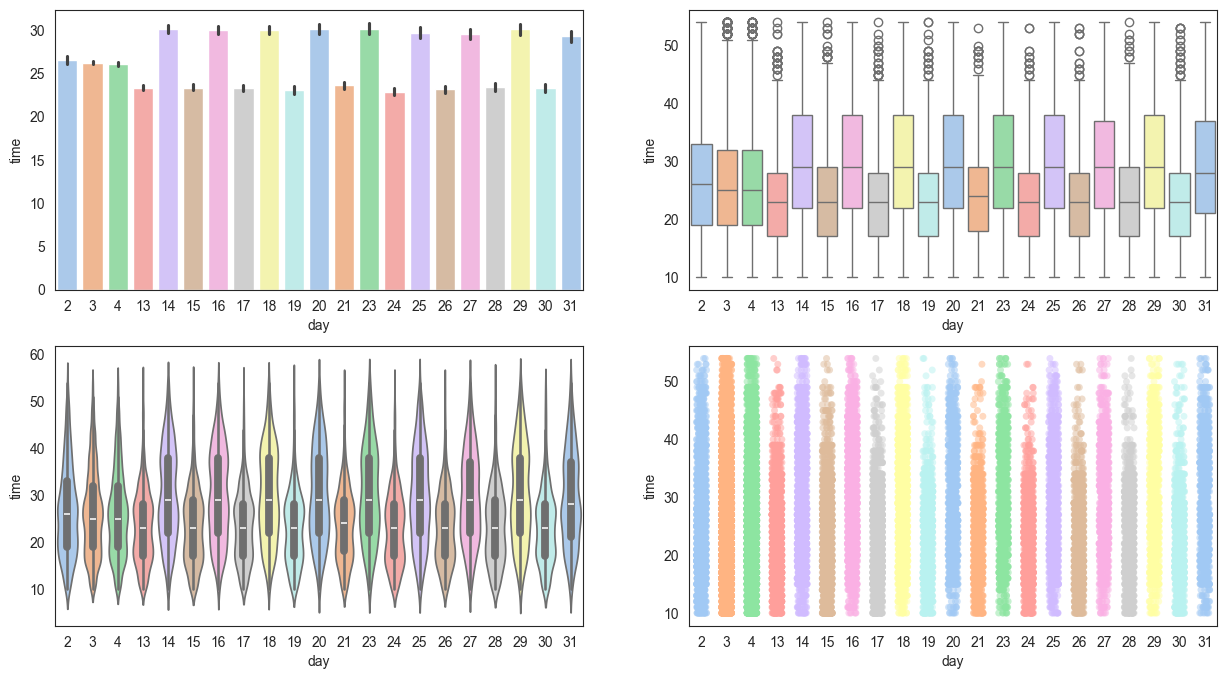

In [175]:
num_cat('time','day')

(1) 3rd and 4th days of the month has highest number of deliveries at 42% of total order.  
(2) there is not enough information available from this variable, we might drop this. 

# Month

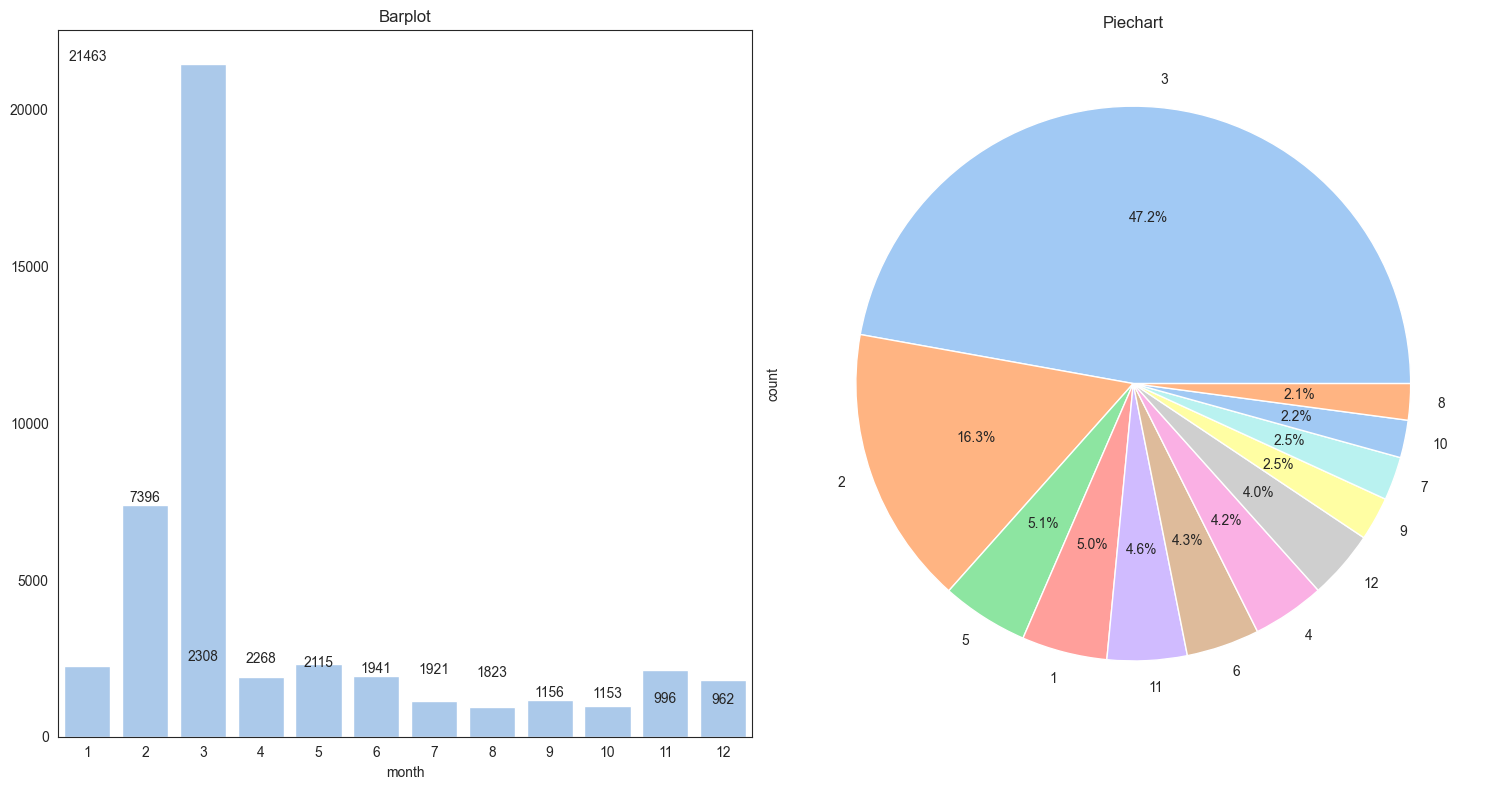

There are 12 unique values in month column 

There are 0.0% missing values in month column 

month
3     21463
2      7396
5      2308
1      2268
11     2115
6      1941
4      1921
12     1823
9      1156
7      1153
10      996
8       962
Name: count, dtype: int64 



In [176]:
uni_cat('month')

p_value : 0.0000 

Atleast one group has mean that is significantly different 



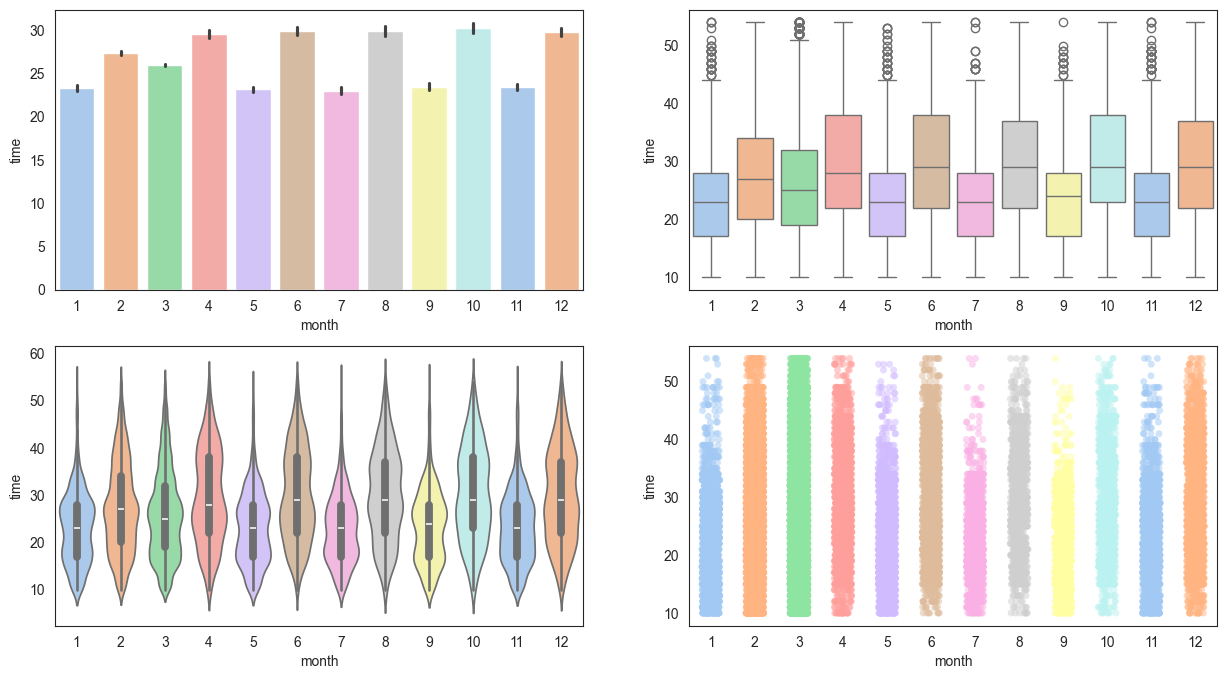

In [177]:
num_cat('time','month')

(1) Februrary and March has highest number of deliveries at 62% of total order.  
(2) there is not enough information available from this variable, we might drop this.

# Day of Week

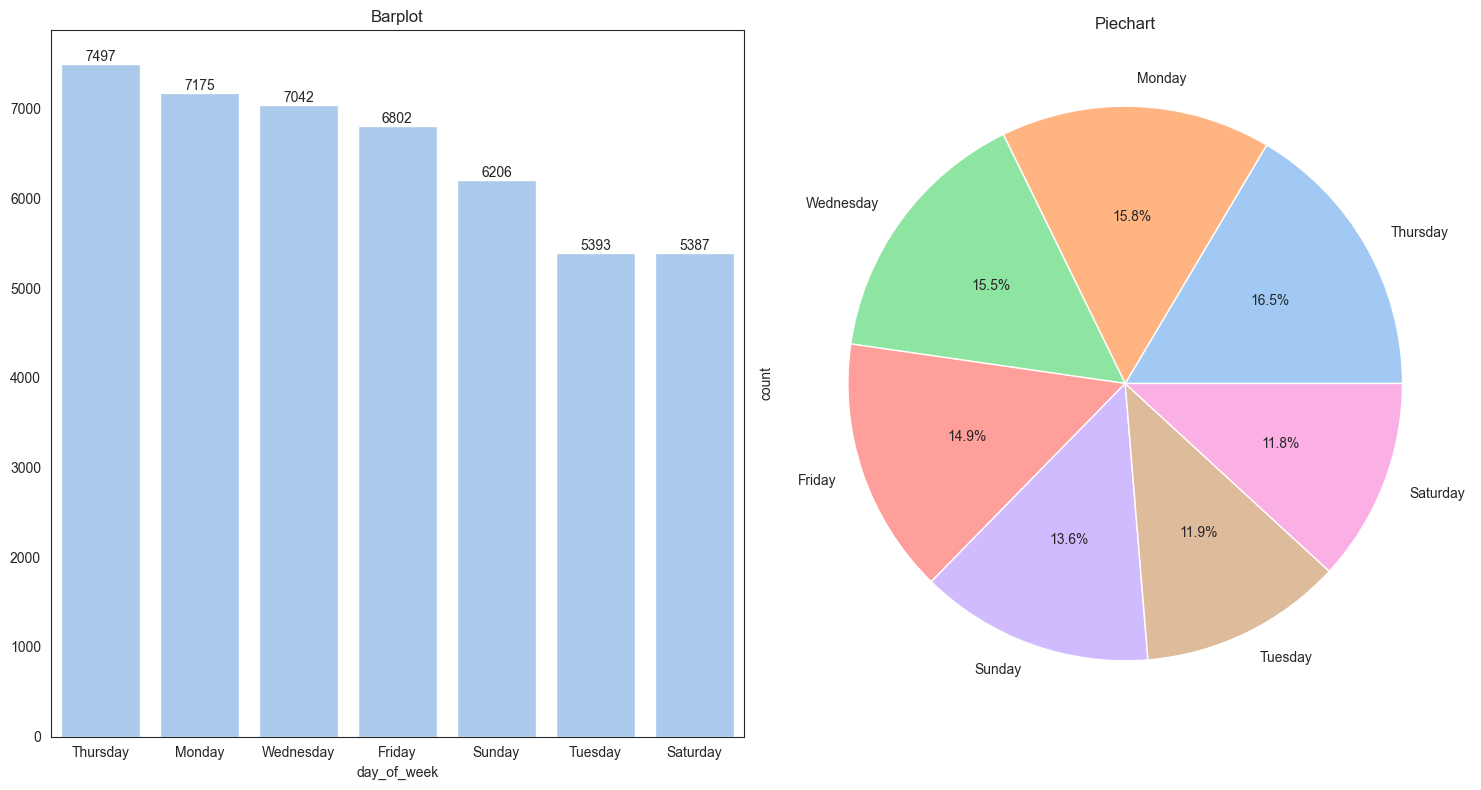

There are 7 unique values in day_of_week column 

There are 0.0% missing values in day_of_week column 

day_of_week
Thursday     7497
Monday       7175
Wednesday    7042
Friday       6802
Sunday       6206
Tuesday      5393
Saturday     5387
Name: count, dtype: int64 



In [178]:
uni_cat('day_of_week')

p_value : 0.0000 

Atleast one group has mean that is significantly different 



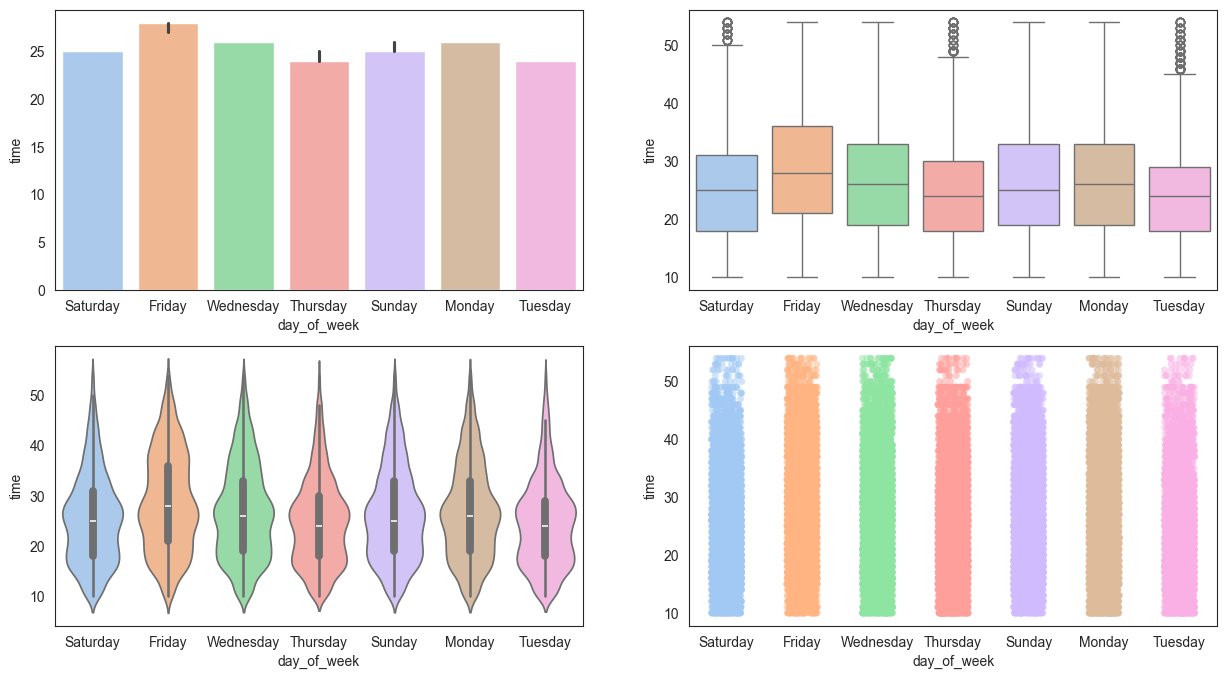

In [179]:
num_cat('time','day_of_week',estimator=np.median)

(1) Thursday has the highest number of orders and Tuesday has the lowest.  
(2) Median delivery time is highest on at 27-28 minutes for Friday and lowest on 24 minutes for Tuesday.

# Pick_up time

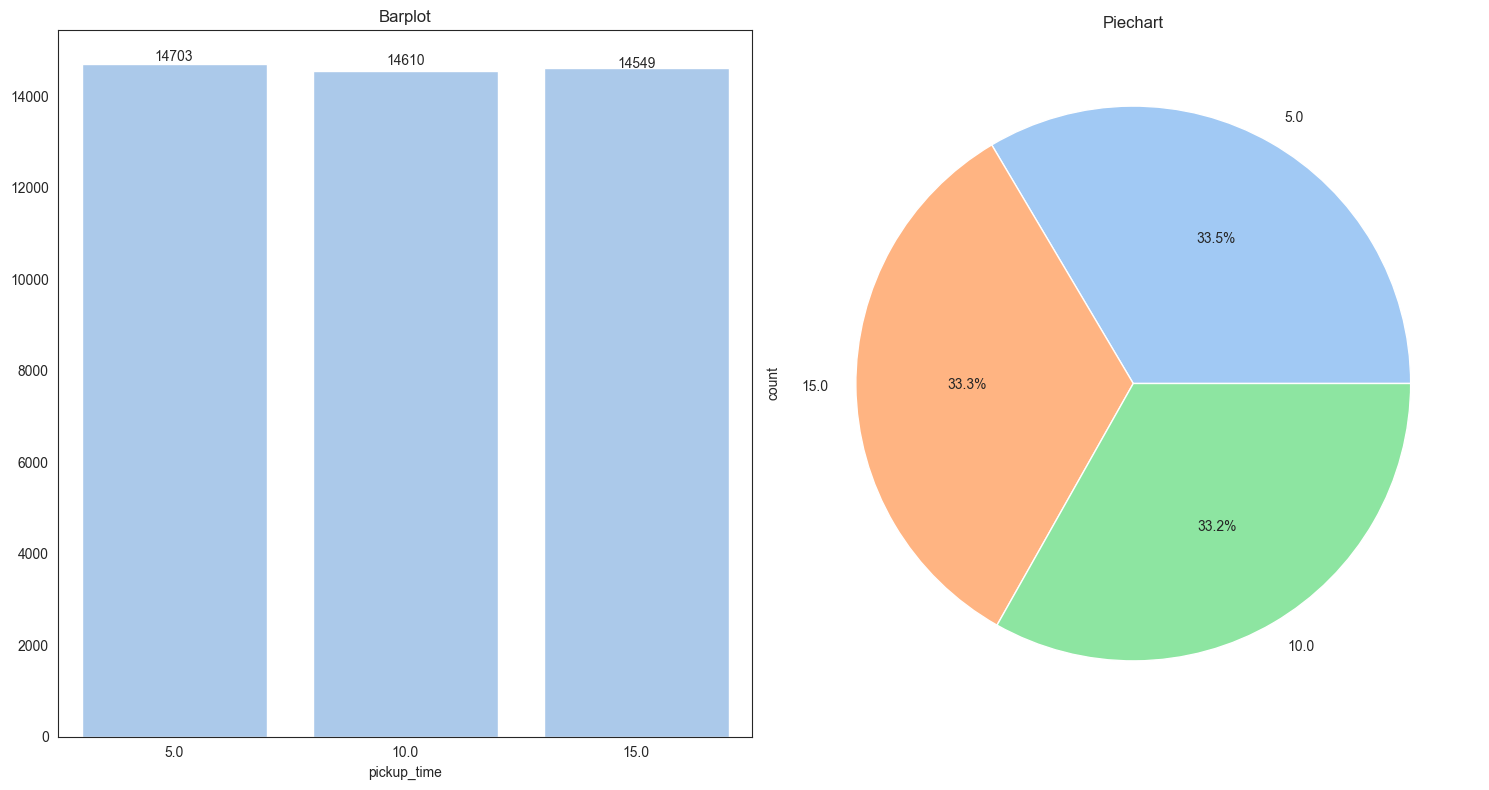

There are 3 unique values in pickup_time column 

There are 4.0% missing values in pickup_time column 

pickup_time
5.0     14703
15.0    14610
10.0    14549
Name: count, dtype: int64 



In [180]:
uni_cat('pickup_time')

p_value : 0.1882 

There is no significant difference between the means of the groups 



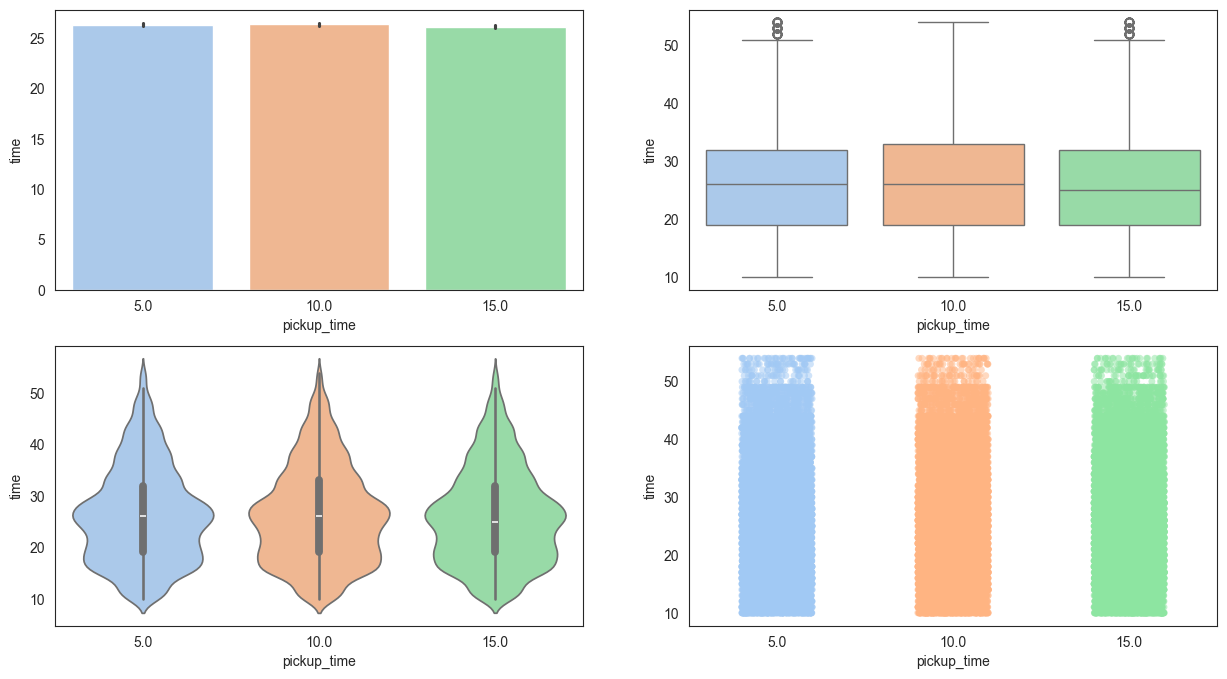

In [181]:
num_cat('time','pickup_time')

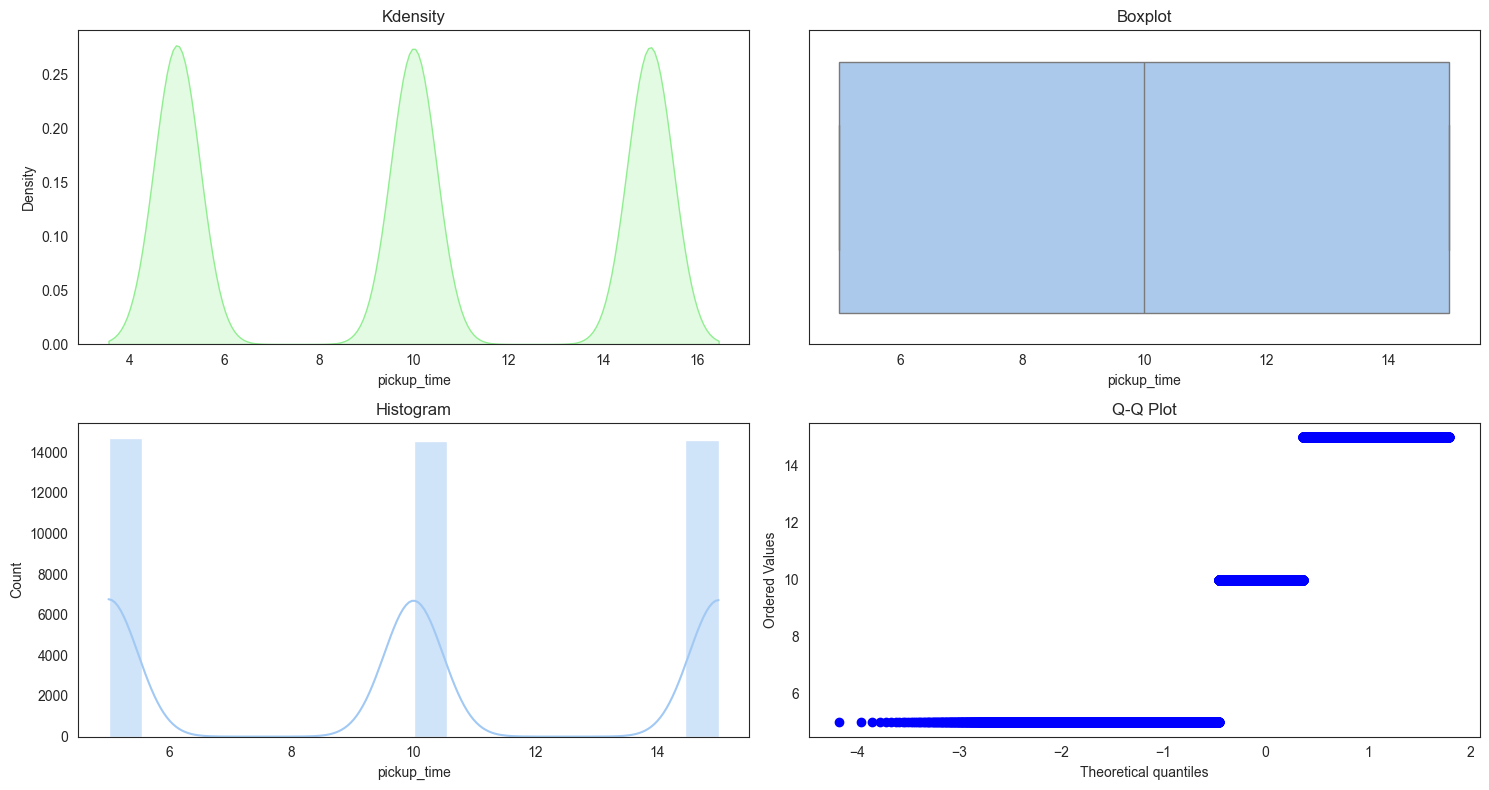

count    43862.000000
mean         9.989399
std          4.087516
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: pickup_time, dtype: float64 

Skewness : 0.0039000996865742963 

Data is relativly normally distributed 

------Shapiro wilk test of Normality---------- 

p_value for Shapiro wilk : 0.0000 

Data is not normally distributed 

------Outliers test---------- 

Upper Bound is nan and Lower Bound is nan
Data does not have outliers 

Kurtosis : -1.5036817001373752 

Some Feature Transformation may help 



In [195]:
uni_num('pickup_time')

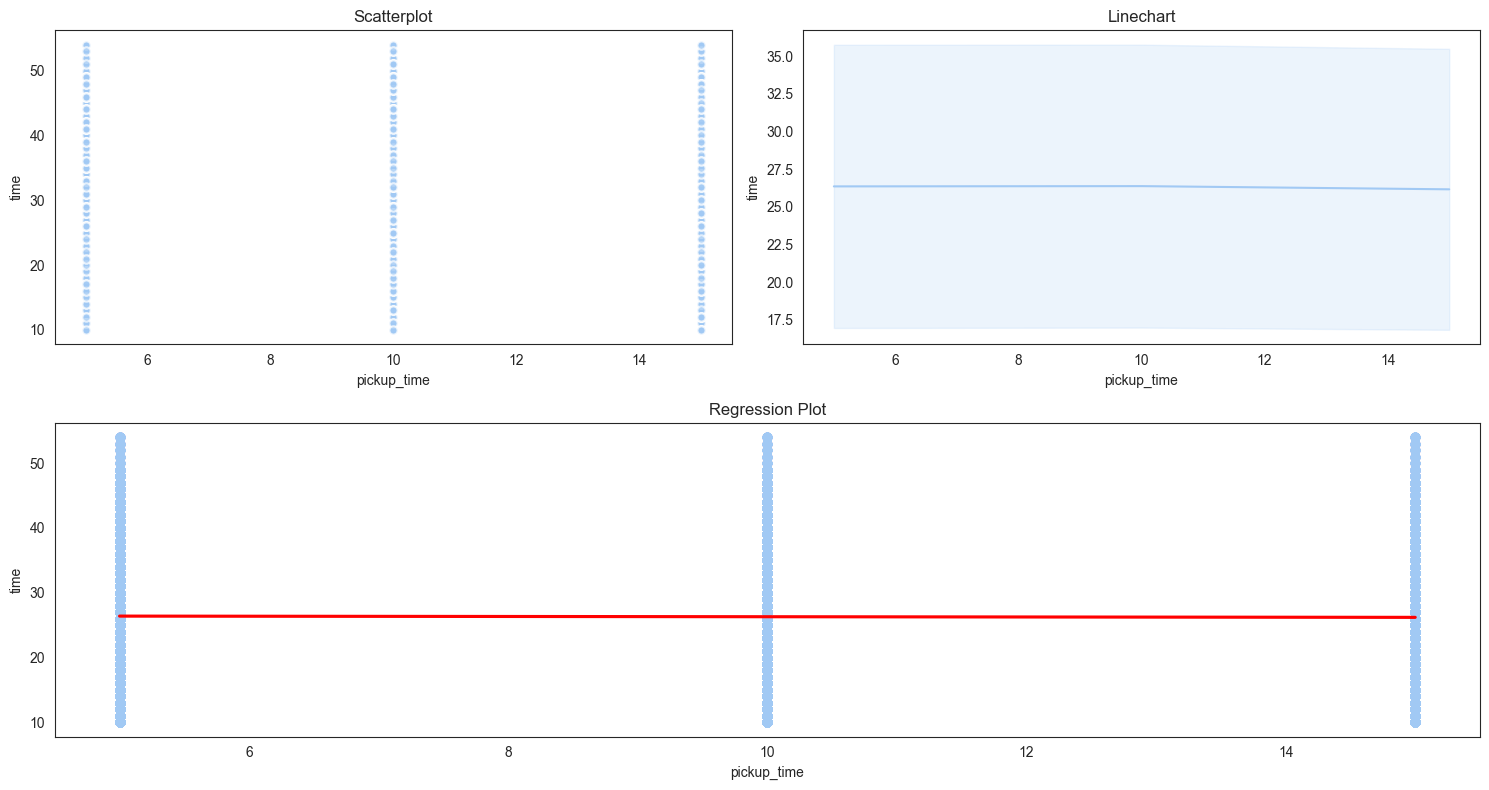

Pearson Correlation test is reliable if both data is normally distributed or their relationship is linear.
pearson coeffient = -0.0083 and p_value =  0.1092
There is No relation between time and pickup_time
--------------------------------------------------
Spearman Correlation Rank test is reliable without assuming any distribution of the data and their relationship is not linear.
Spearman coeffient = -0.0071 and p_value =  0.1654
There is No relation between time and pickup_time
--------------------------------------------------
Simple Linear Regresson Test (OLS) 

coefficient = -0.0189 and p_value =  0.1092
A 1 unit change in pickup_time is correlated with -0.0189 Unit change in time
R2 value =  0.0001
 0.0068% of total variation in time Can be explained by pickup_time
There is No relation between time and pickup_time


In [196]:
num_num('time','pickup_time')

(1) Order Pickup time doesn't has any visible and statistical impact on the delivery time.

# Is weekend

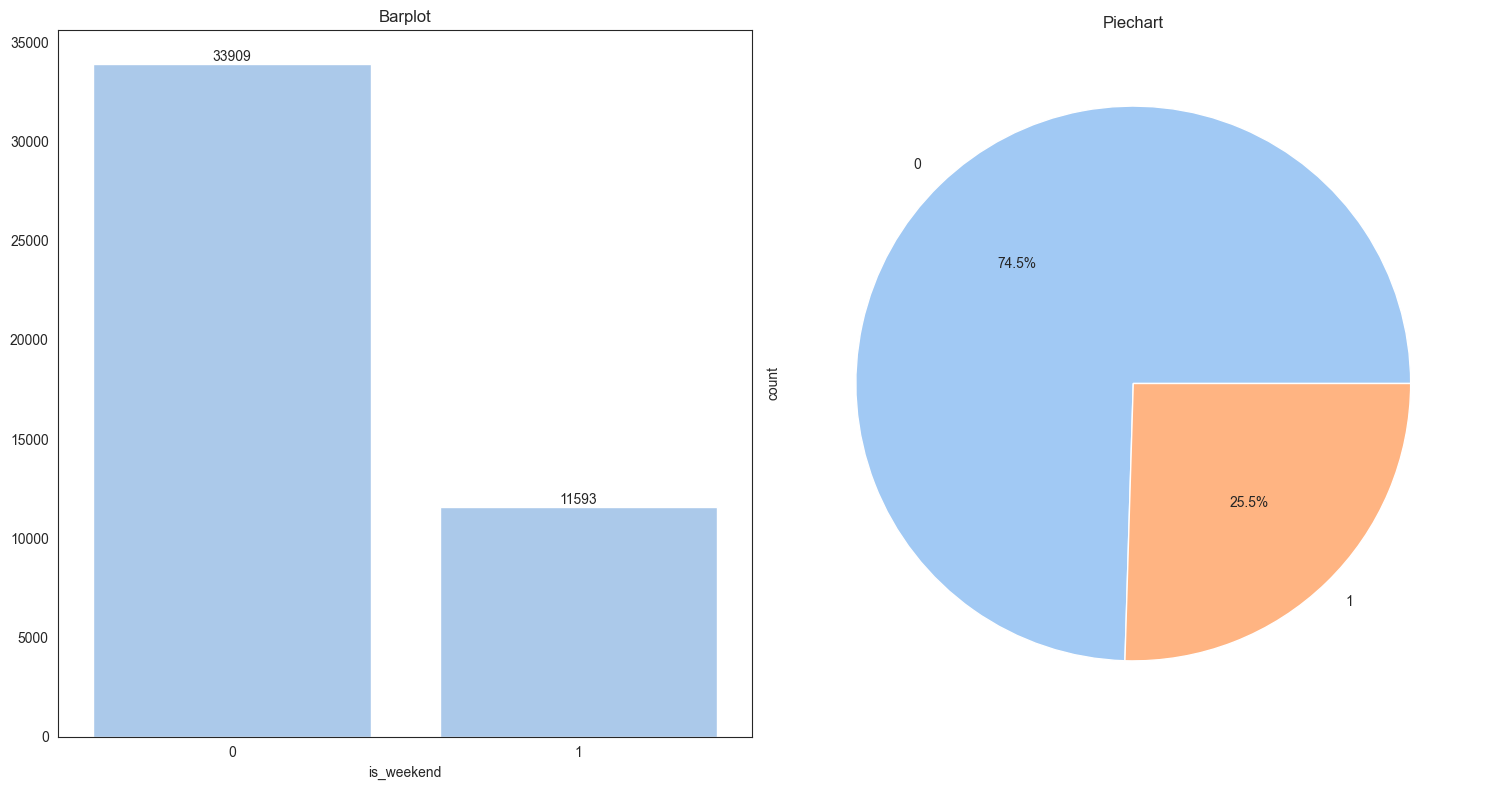

There are 2 unique values in is_weekend column 

There are 0.0% missing values in is_weekend column 

is_weekend
0    33909
1    11593
Name: count, dtype: int64 



In [182]:
uni_cat('is_weekend')

p_value : 0.0000 

There is a significant difference between the means of the groups 



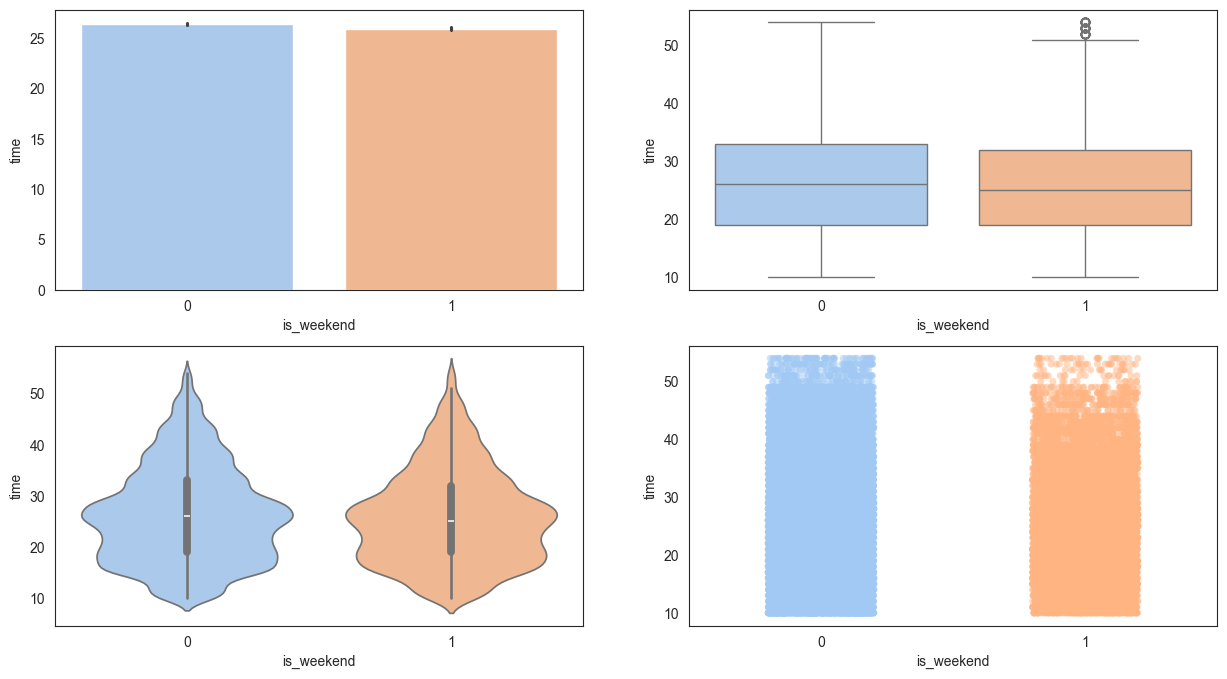

In [183]:
num_cat('time','is_weekend')

(1) Median delivery time is slightly lower in weekend with simillar distribution with weekdays according to statistical tests.  
(2) but visually the mean delivery time is same for both type of days.

# Time of day

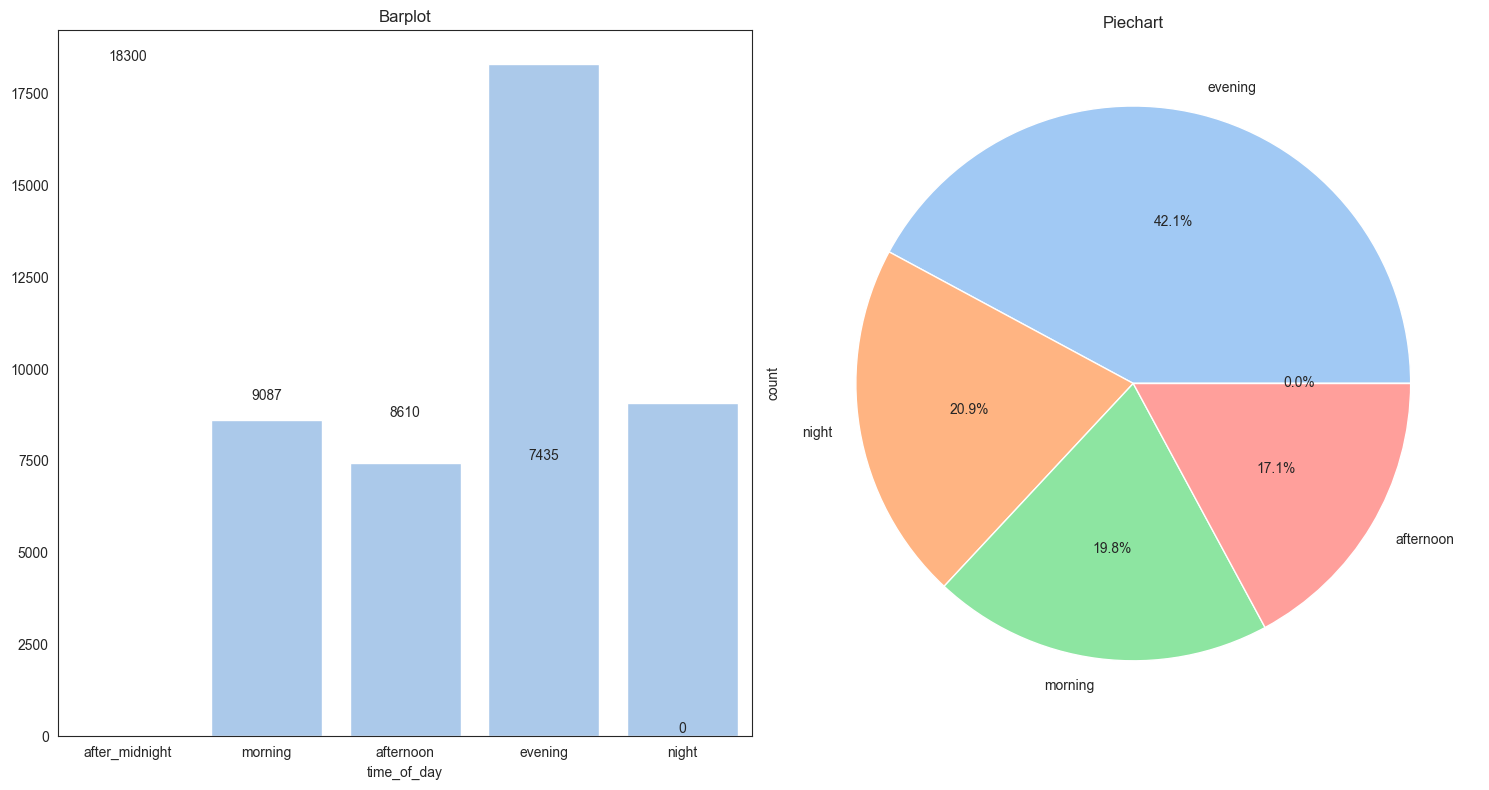

There are 4 unique values in time_of_day column 

There are 5.0% missing values in time_of_day column 

time_of_day
evening           18300
night              9087
morning            8610
afternoon          7435
after_midnight        0
Name: count, dtype: int64 



In [184]:
uni_cat('time_of_day')

p_value : nan 

There is no significant difference between the means of the groups 



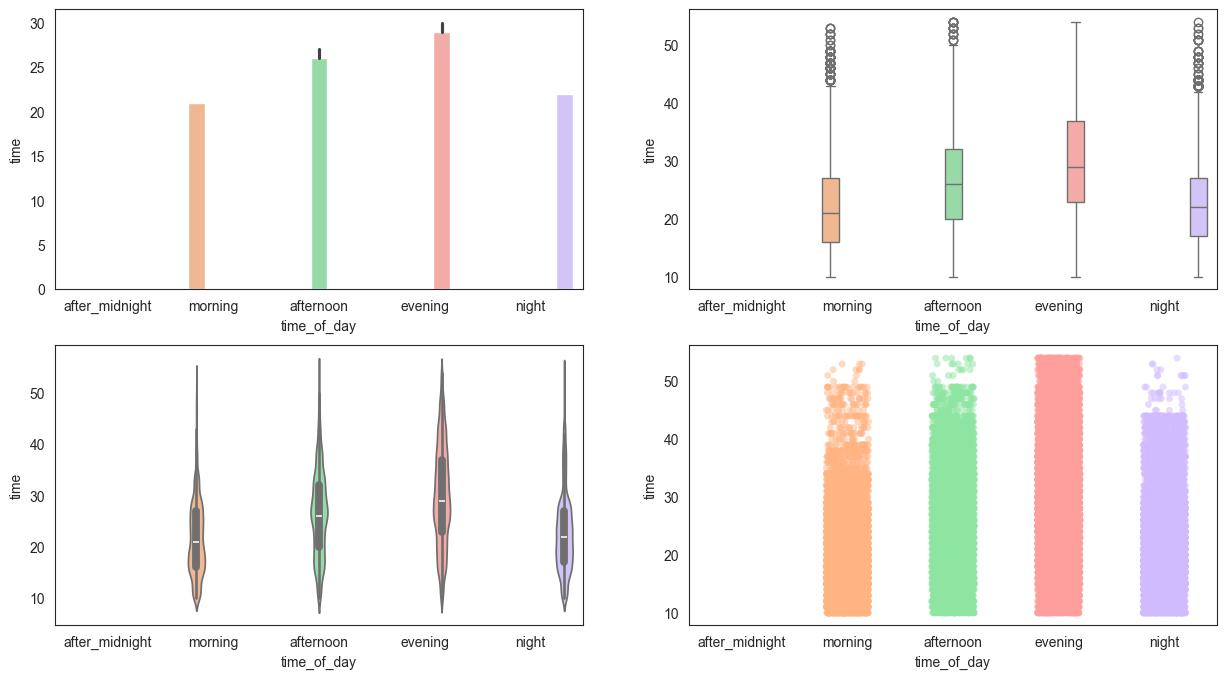

In [185]:
num_cat('time','time_of_day',estimator=np.median)

(1) Most Numbers of orders are during the evening with highest median delivery time of 30 minutes.  
(2) Lowest Median delivery time is during the morning with 22-23 minutes.

# Multivariate Analysis

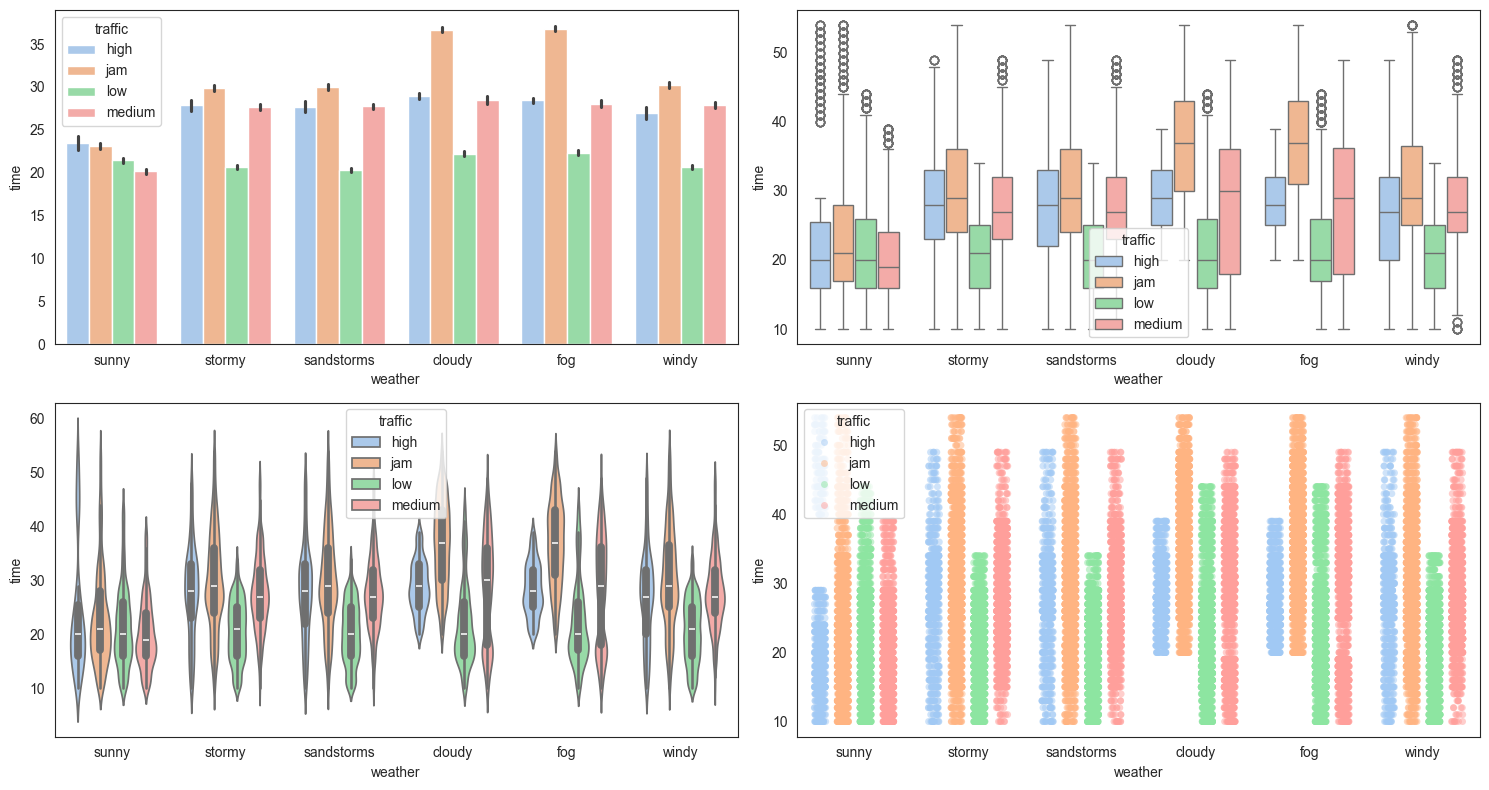

In [186]:
multivariate_analysis('time','weather','traffic')


(1) There are some extreme delivery time when it's cloudy and fog and traffic is heavy at mean close to 36 minutes.  
(2) Regardless of the traffic the delivery time is lower for sunny weather.  
(3) The lowest mean delivery time for sunny weather and medium traffic is 20 minutes.  

In [187]:
cleaned_df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_lat', 'restaurant_long',
       'delivery_lat', 'delivery_long', 'weather', 'traffic',
       'vehicle_condition', 'order_type', 'vehicle_type',
       'multiple_deliveries', 'festival', 'city_type', 'time', 'city_name',
       'age_cat', 'ratings_cat', 'distance_km', 'distance_km_cat', 'day',
       'month', 'day_of_week', 'is_weekend', 'pickup_time', 'order_time_hour',
       'time_of_day', 'pickup_time_cat', 'ratings_transformed'],
      dtype='object')

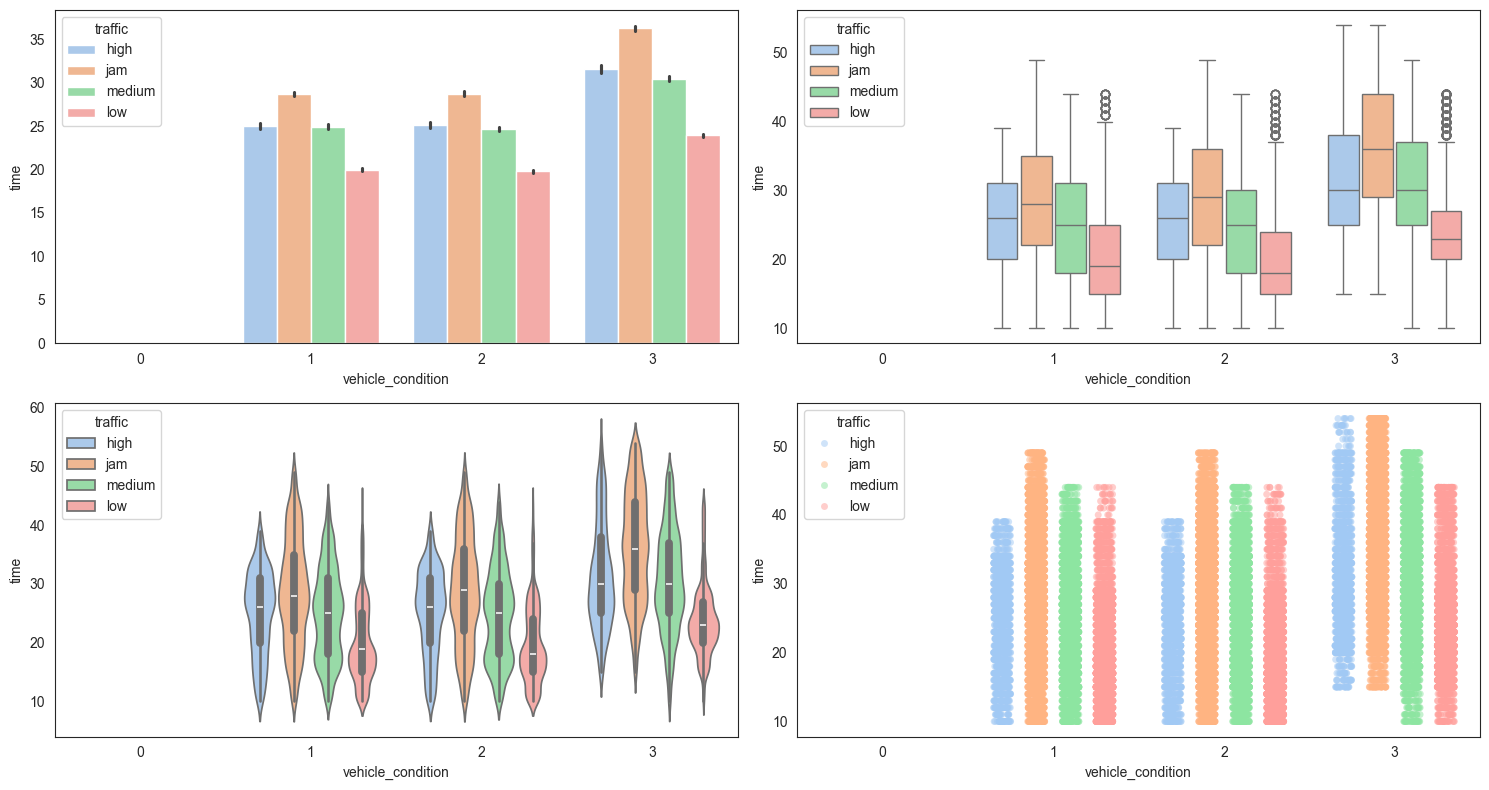

In [188]:
multivariate_analysis('time','vehicle_condition','traffic')

(1) Vehicle Condition 3 has higher mean delivery time regardless of the traffic.

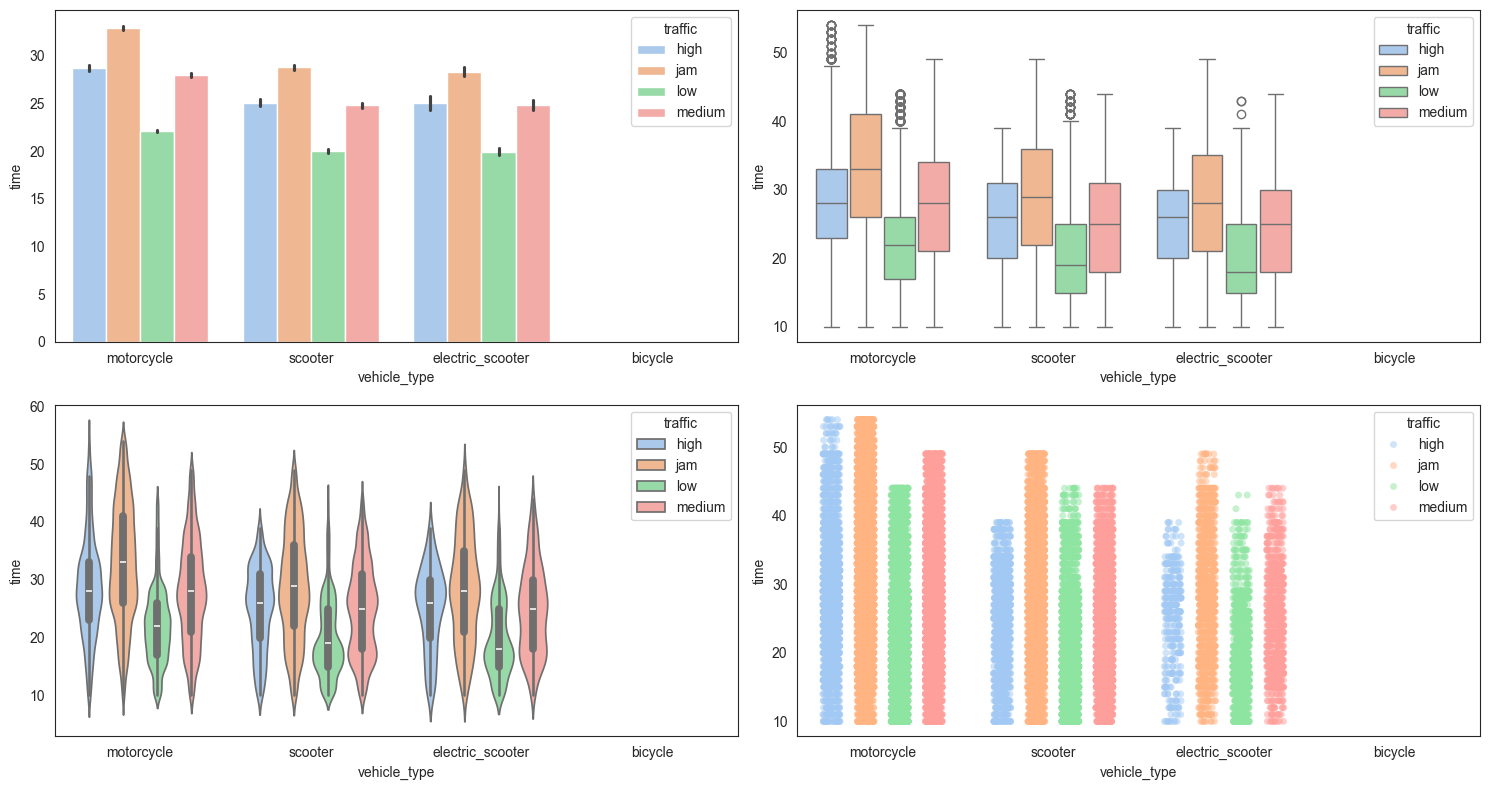

In [189]:
multivariate_analysis('time','vehicle_type','traffic')

(1) Electric Scooter has the lowest Mean delivery time regardless of the traffic with less outliers.  
(2) Motorcycle has the highest median delivery time regardless of the traffic with more outliers.

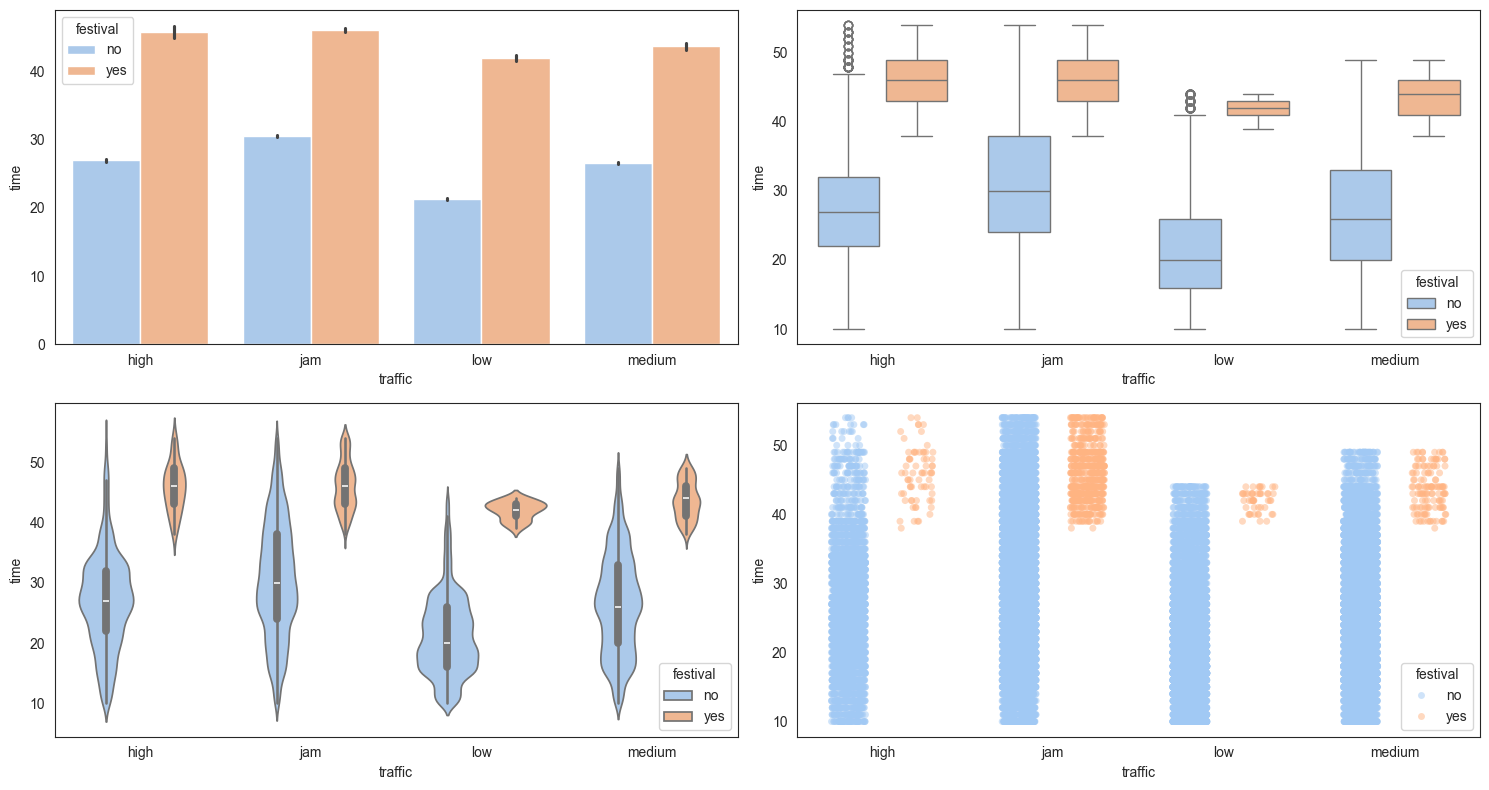

In [190]:
multivariate_analysis('time','traffic','festival')

(1) Regardless of the traffic the delivery time is higher during festivals.  
But there are so less data for festivals.  
(2) There is more traffic jam on festival days.

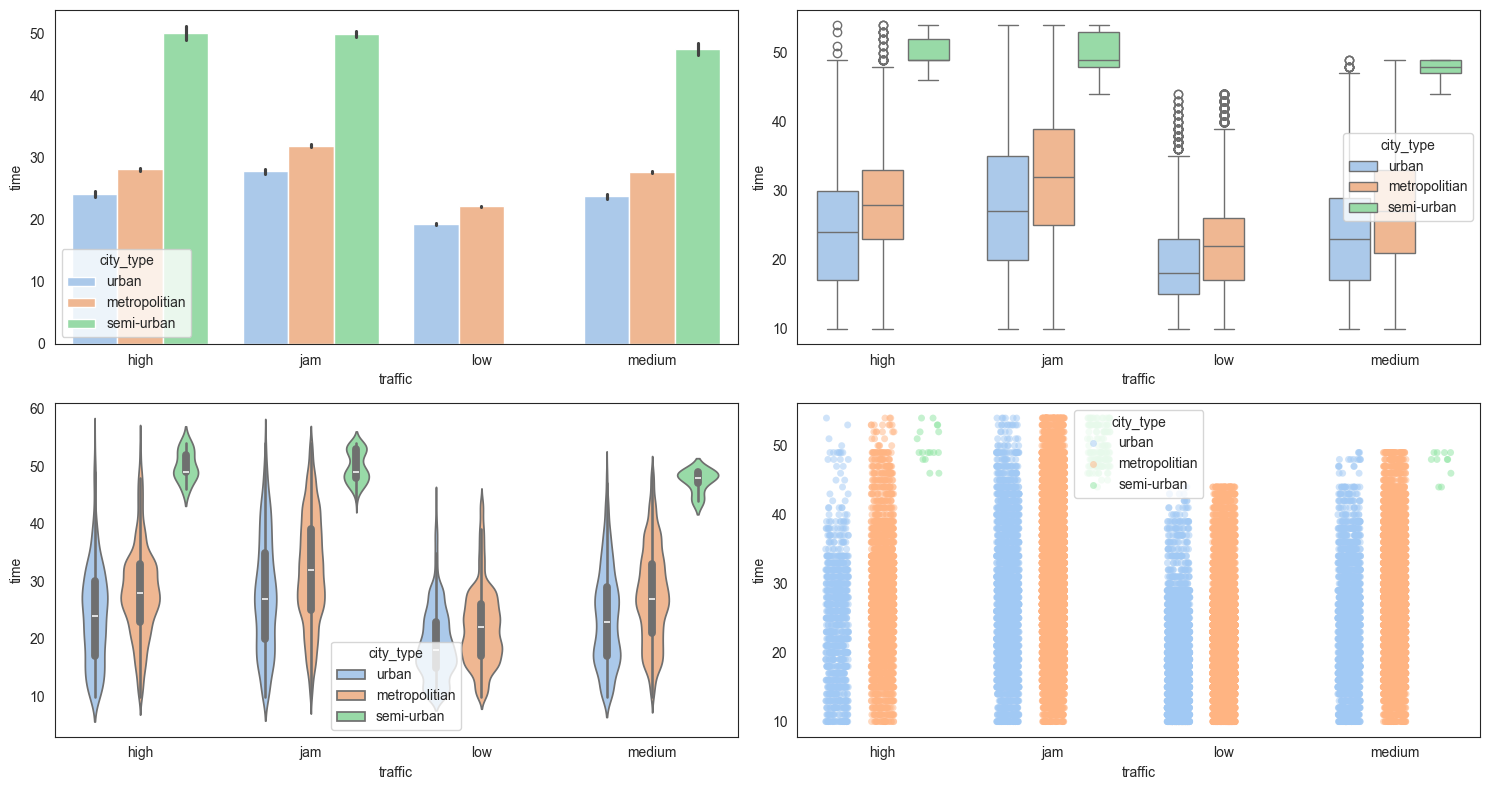

In [191]:
multivariate_analysis('time','traffic','city_type')

(1) Simillar distribution of median delivery time for all cities regardless of the traffic.  
(2) Semi-urban has the highest mean delivery time regardless of the traffic, But there is not enough data for Semi-urban.

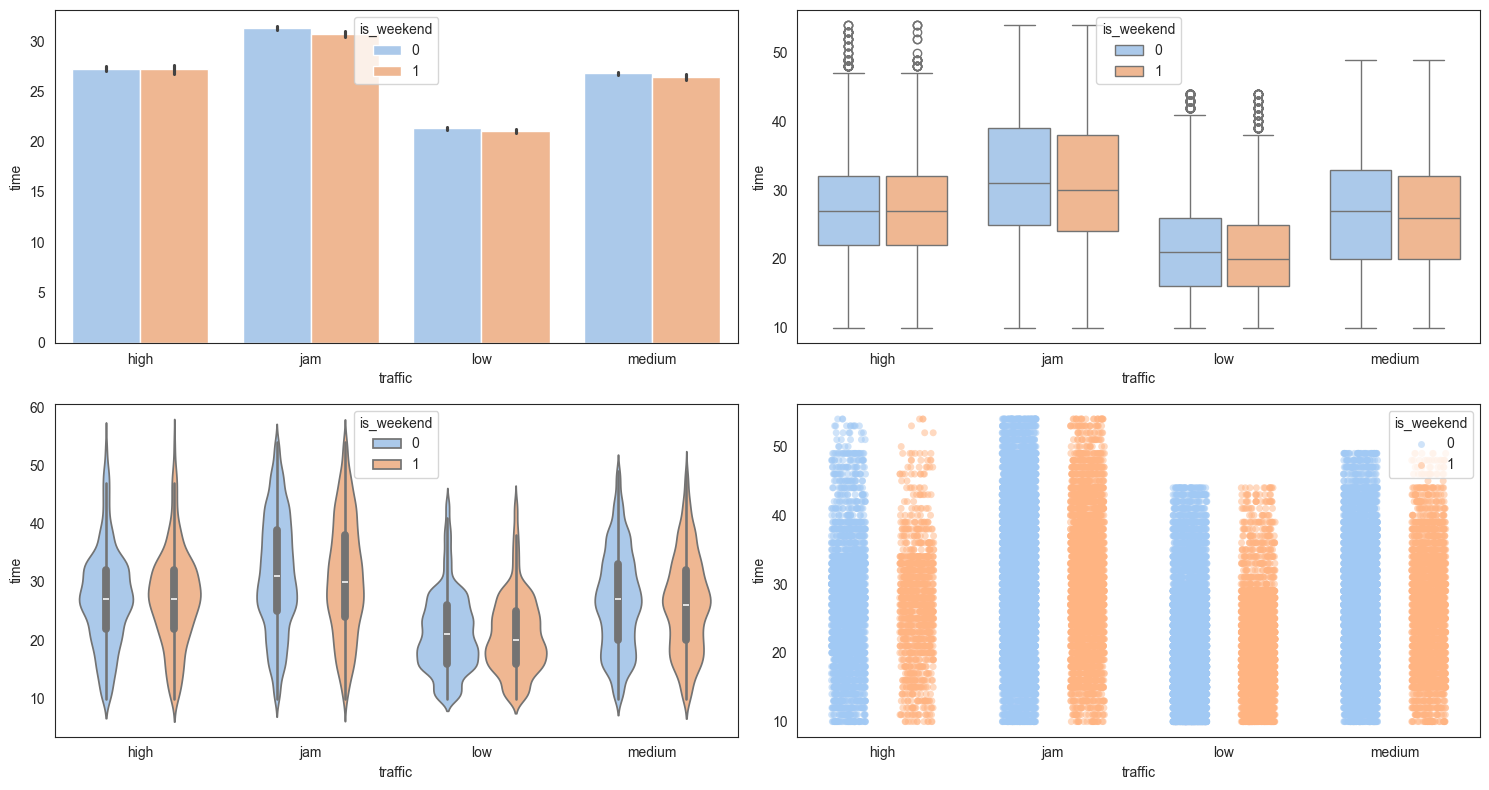

In [192]:
multivariate_analysis('time','traffic','is_weekend')

(1) Regardless of the weekend the mean delivery time is simillar for all traffic situations.

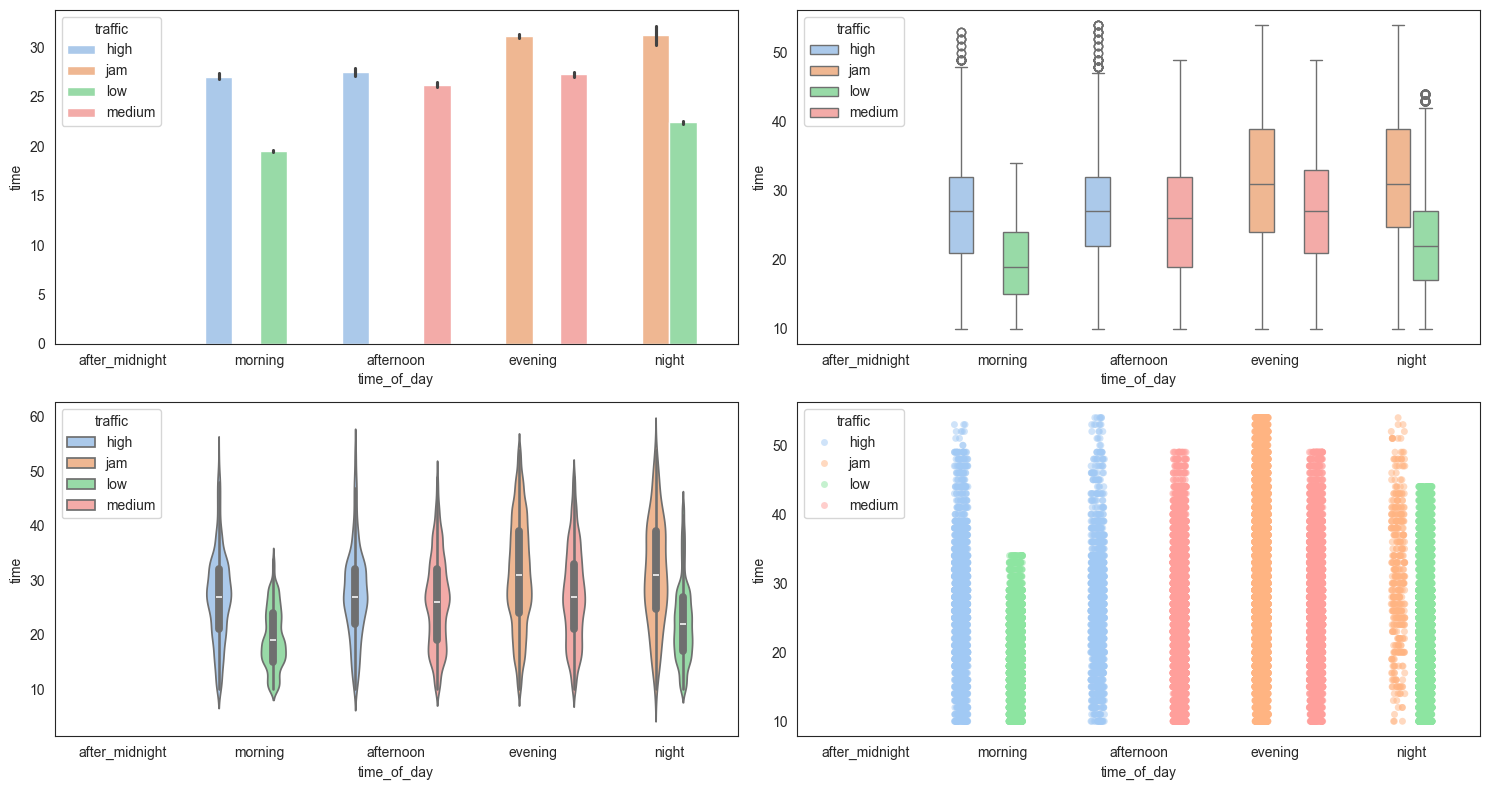

In [193]:
multivariate_analysis('time','time_of_day','traffic')

(1) Not enough data for all time of day.  
(2) traffic is lowest in the morning with the lowest mean delivary time of 19 minutes when there is no traffic.  
(3) traffic is highest in the evening and night with the highest mean delivary time of 31 minutes when it's jam